# 🎓 AI-Based Course Recommendation System

## Project Overview

The AI-Based Course Recommendation System is a Machine Learning project designed to recommend the most suitable professional course for students based on their academic profile, technical skills, and career interests.

The system analyzes multiple factors such as educational background, programming skills, questionnaire responses, and preferred career domain to predict the course that best matches the student's profile.

---

## Objectives

- Analyze student profiles.
- Evaluate technical skill levels.
- Understand student interests through a questionnaire.
- Recommend the most suitable professional course.
- Display detailed course information after prediction.

---

## Datasets Used

This project uses five datasets:

1. **students.csv**
   - Student demographic and academic information.

2. **student_skills.csv**
   - Technical skill ratings for each student.

3. **student_answers.csv**
   - Questionnaire responses.

4. **questions.csv**
   - Questionnaire metadata.

5. **courses.csv**
   - Course information used for displaying recommendations.


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Load the datasets

In [2]:
students_df = pd.read_csv("../dataset/students.csv")
skills_df = pd.read_csv("../dataset/student_skills.csv")
questions_df = pd.read_csv("../dataset/questions.csv")
answers_df = pd.read_csv("../dataset/student_answers.csv")
courses_df = pd.read_csv("../dataset/courses.csv")

print(f"students dataset = {students_df.shape}")
print(f"student skills   = {skills_df.shape}")
print(f"questions        = {questions_df.shape}")
print(f"students answers = {answers_df.shape}")
print(f"courses          = {courses_df.shape}")

students dataset = (10000, 15)
student skills   = (50000, 3)
questions        = (10, 4)
students answers = (10000, 11)
courses          = (12, 10)


## Data inspecting

In [3]:
datasets = {
    "Students":students_df,
    "students skills":skills_df,
    "Questions":questions_df,
    "Answers":answers_df,
    "Courses":courses_df
}

for name,df in datasets.items():
    print("\n"+"="*70)
    print(f"{name} dataset")
    print("="*70)
    display(df.head())


Students dataset


,student_id,name,age,gender,email,phone,education_level,qualification,specialization,background,college_name,graduation_year,cgpa,backlogs,preferred_domain
0,STU00001,Anika Seth,22,Female,anikaseth115@gmail.com,9126855092,Undergraduate,B.Tech,ECE,No,College of Engineering Trivandrum,2026,7.91,No,Testing
1,STU00002,Dakshesh Comar,22,Male,daksheshcomar239@gmail.com,9642621108,Undergraduate,B.Tech,CSE,Yes,"Jain University, Bengaluru",2026,6.51,No,React
2,STU00003,Pushti Ram,30,Male,pushtiram826@gmail.com,9271432881,Working Professional,M.Sc,Data Science,Yes,"Jain University, Bengaluru",2020,8.77,No,Python
3,STU00004,Wriddhish Sarkar,30,Male,wriddhishsarkar353@gmail.com,9748245888,Working Professional,MBA,Business Administration,No,"Anna University, Chennai",2021,8.69,No,Data Science
4,STU00005,Parth Bora,19,Male,parthbora566@gmail.com,9414797776,12th,12th,Commerce,No,"St. Thomas Higher Secondary School, Thrissur",2026,7.46,No,Testing



students skills dataset


,student_id,skill,experience_level
0,STU00001,Business Communication,2
1,STU00001,Git,2
2,STU00001,MS Office,2
3,STU00001,Python,2
4,STU00002,Data Structures,4



Questions dataset


,question_code,category,question,response_scale
0,Q1,Programming,How would you rate your overall programming kn...,1-5
1,Q2,Web Development,How interested are you in developing websites ...,1-5
2,Q3,Mobile Development,How interested are you in developing mobile ap...,1-5
3,Q4,Artificial Intelligence,How interested are you in Artificial Intellige...,1-5
4,Q5,Data & Analytics,How interested are you in Data Science and Bus...,1-5



Answers dataset


,student_id,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
0,STU00001,3,1,2,3,1,2,2,1,4,5
1,STU00002,4,4,1,2,2,4,1,2,2,3
2,STU00003,5,5,2,5,4,5,1,2,2,5
3,STU00004,4,2,3,5,5,2,1,3,2,5
4,STU00005,2,2,1,2,3,2,1,2,4,3



Courses dataset


,course_id,course_name,category,course_description,certification,placement_support,skills_taught,roadmap,course_url,skills_list
0,C001,Python Full Stack Development,Python,"Learn Python, Django, REST APIs, MySQL, Git an...",Yes,Yes,"Python, Django, HTML, CSS, JavaScript, MySQL, ...",Python → HTML/CSS → JavaScript → Django → REST...,https://cybersquare.pro/,"['Python', 'Django', 'HTML', 'CSS', 'JavaScrip..."
1,C002,MERN Stack Development,MERN Stack,"Master MongoDB, Express.js, React and Node.js ...",Yes,Yes,"MongoDB, Express.js, React, Node.js, JavaScrip...",HTML/CSS → JavaScript → React → Node.js → Expr...,https://cybersquare.pro/,"['MongoDB', 'Express.js', 'React', 'Node.js', ..."
2,C003,Flutter Development,Flutter,Develop cross-platform Android and iOS applica...,Yes,Yes,"Flutter, Dart, Firebase, REST API",Dart → Flutter → UI → Firebase → API Integrati...,https://cybersquare.pro/,"['Flutter', 'Dart', 'Firebase', 'REST API']"
3,C004,React Front End Development,React,Build responsive and interactive frontend appl...,Yes,Yes,"React, JavaScript, HTML, CSS, API Integration",HTML/CSS → JavaScript → React → Components → R...,https://cybersquare.pro/,"['React', 'JavaScript', 'HTML', 'CSS', 'API In..."
4,C005,Angular Development,Angular,Create scalable web applications using Angular...,Yes,Yes,"Angular, TypeScript, HTML, CSS, RxJS",TypeScript → Angular → Components → Services →...,https://cybersquare.pro/,"['Angular', 'TypeScript', 'HTML', 'CSS', 'RxJS']"


In [4]:
## data types
for name,df in datasets.items():
    print("\n"+"="*50)
    print(name)
    print("="*50)

    display(pd.DataFrame(
        {
            "Column": df.columns,
            "Data Type": df.dtypes.astype(str).values
        }
    ))
    


Students


,Column,Data Type
0,student_id,object
1,name,object
2,age,int64
3,gender,object
4,email,object
5,phone,int64
6,education_level,object
7,qualification,object
8,specialization,object
9,background,object



students skills


,Column,Data Type
0,student_id,object
1,skill,object
2,experience_level,int64



Questions


,Column,Data Type
0,question_code,object
1,category,object
2,question,object
3,response_scale,object



Answers


,Column,Data Type
0,student_id,object
1,Q1,int64
2,Q2,int64
3,Q3,int64
4,Q4,int64
5,Q5,int64
6,Q6,int64
7,Q7,int64
8,Q8,int64
9,Q9,int64



Courses


,Column,Data Type
0,course_id,object
1,course_name,object
2,category,object
3,course_description,object
4,certification,object
5,placement_support,object
6,skills_taught,object
7,roadmap,object
8,course_url,object
9,skills_list,object


In [5]:
# Missing values check
for name,df in datasets.items():
    print("\n"+"="*50)
    print(name + " datasets")
    print("="*50)

    missing = df.isnull().sum()

    display(pd.DataFrame({
        "Columns":missing.index,
        "Missing values": missing.values
    }))



Students datasets


,Columns,Missing values
0,student_id,0
1,name,0
2,age,0
3,gender,0
4,email,0
5,phone,0
6,education_level,0
7,qualification,0
8,specialization,0
9,background,0



students skills datasets


,Columns,Missing values
0,student_id,0
1,skill,0
2,experience_level,0



Questions datasets


,Columns,Missing values
0,question_code,0
1,category,0
2,question,0
3,response_scale,0



Answers datasets


,Columns,Missing values
0,student_id,0
1,Q1,0
2,Q2,0
3,Q3,0
4,Q4,0
5,Q5,0
6,Q6,0
7,Q7,0
8,Q8,0
9,Q9,0



Courses datasets


,Columns,Missing values
0,course_id,0
1,course_name,0
2,category,0
3,course_description,0
4,certification,0
5,placement_support,0
6,skills_taught,0
7,roadmap,0
8,course_url,0
9,skills_list,0


In [6]:
# duplicate values
for names,df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{names:<15} : {duplicates}")

Students        : 0
students skills : 0
Questions       : 0
Answers         : 0
Courses         : 0


In [7]:
students_df.describe()

,age,phone,graduation_year,cgpa
count,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,22.300700,9.545365e+09,2024.664100,7.339323
std,3.535835,2.584744e+08,2.024569,0.981572
min,15.000000,9.100255e+09,2017.000000,5.500000
25%,20.000000,9.324302e+09,2024.000000,6.620000
50%,22.000000,9.540301e+09,2026.000000,7.310000
75%,24.000000,9.766644e+09,2026.000000,8.020000
max,30.000000,9.999871e+09,2026.000000,9.950000


In [8]:
skills_df.describe().T

,count,mean,std,min,25%,50%,75%,max
experience_level,50000.0,2.51772,1.194652,1.0,2.0,2.0,3.0,5.0


In [9]:
answers_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Q1,10000.0,2.8978,1.455942,1.0,2.0,3.0,4.0,5.0
Q2,10000.0,2.9202,1.258090,1.0,2.0,3.0,4.0,5.0
Q3,10000.0,1.9354,0.664433,1.0,2.0,2.0,2.0,5.0
Q4,10000.0,2.6327,1.160399,1.0,2.0,2.0,4.0,5.0
Q5,10000.0,2.9440,1.129244,1.0,2.0,3.0,4.0,5.0
Q6,10000.0,2.6635,1.145338,1.0,2.0,2.0,4.0,5.0
Q7,10000.0,1.6509,0.476709,1.0,1.0,2.0,2.0,2.0
Q8,10000.0,2.0575,0.653021,1.0,2.0,2.0,2.0,5.0
Q9,10000.0,2.0881,0.689482,1.0,2.0,2.0,2.0,5.0
Q10,10000.0,4.0086,0.911707,1.0,3.0,4.0,5.0,5.0


#### Categorical analysis

In [10]:
students_df.describe()

,age,phone,graduation_year,cgpa
count,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,22.300700,9.545365e+09,2024.664100,7.339323
std,3.535835,2.584744e+08,2.024569,0.981572
min,15.000000,9.100255e+09,2017.000000,5.500000
25%,20.000000,9.324302e+09,2024.000000,6.620000
50%,22.000000,9.540301e+09,2026.000000,7.310000
75%,24.000000,9.766644e+09,2026.000000,8.020000
max,30.000000,9.999871e+09,2026.000000,9.950000


In [11]:
categorical_columns = students_df.select_dtypes(include="object").columns
categorical_columns

Index(['student_id', 'name', 'gender', 'email', 'education_level',
       'qualification', 'specialization', 'background', 'college_name',
       'backlogs', 'preferred_domain'],
      dtype='object')

In [12]:
for column in categorical_columns:
    print("\n",column.upper())
    print("-"*30,"\n")
    print(students_df[column].value_counts())
    


 STUDENT_ID
------------------------------ 

student_id
STU00001    1
STU06671    1
STU06664    1
STU06665    1
STU06666    1
           ..
STU03334    1
STU03335    1
STU03336    1
STU03337    1
STU10000    1
Name: count, Length: 10000, dtype: int64

 NAME
------------------------------ 

name
Aryan Padmanabhan    3
Dipta Sengupta       3
Champak Vig          3
Ronith Pant          2
Saksham Choudhry     2
                    ..
Ojasvi Nazareth      1
Ubika Mallick        1
Neha Dhingra         1
Kevin Master         1
Balvan Char          1
Name: count, Length: 9826, dtype: int64

 GENDER
------------------------------ 

gender
Female    5817
Male      4183
Name: count, dtype: int64

 EMAIL
------------------------------ 

email
anikaseth115@gmail.com               1
vinayanair557@gmail.com              1
simonbahl641@gmail.com               1
qadimjani149@gmail.com               1
shivanshom323@gmail.com              1
                                    ..
suhanibaria125@gmail.com

In [13]:
def student_plot(column_name):
    plt.figure(figsize=(10,5))

    ax =sns.countplot(
        data=students_df,
        x=column_name,
        order=students_df[column_name].value_counts().index
    )

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f"{column_name.title()} Distribution")
    plt.xlabel(f"{column_name.title()}")
    plt.ylabel("Number of Students")

    plt.xticks(rotation=30,ha="right")
    plt.tight_layout()

    plt.show()

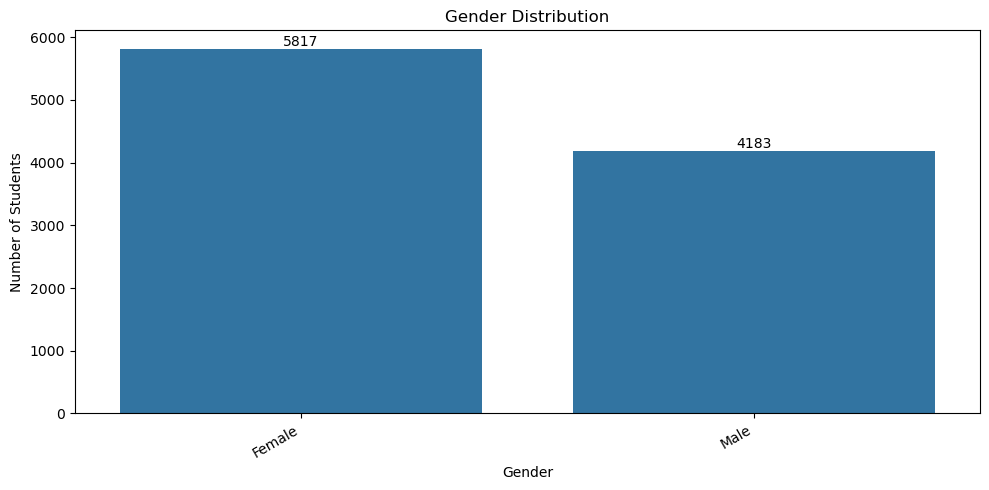

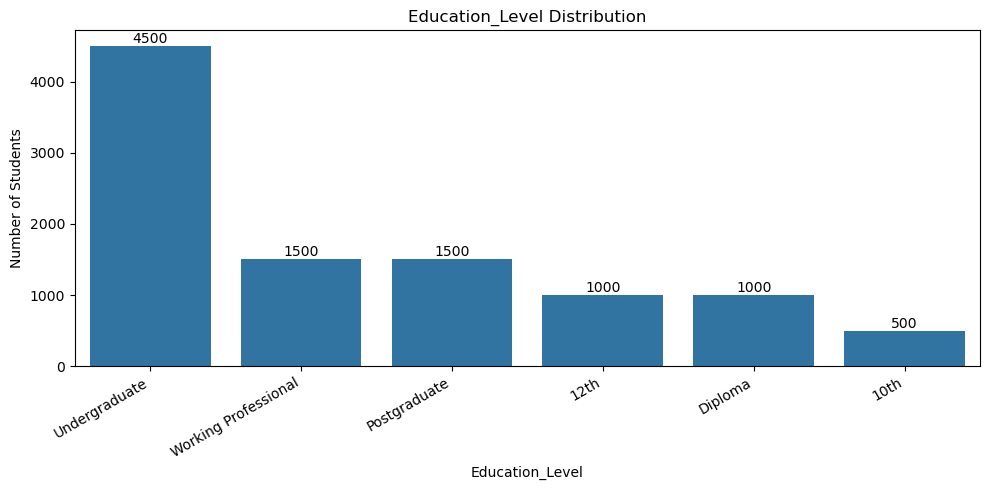

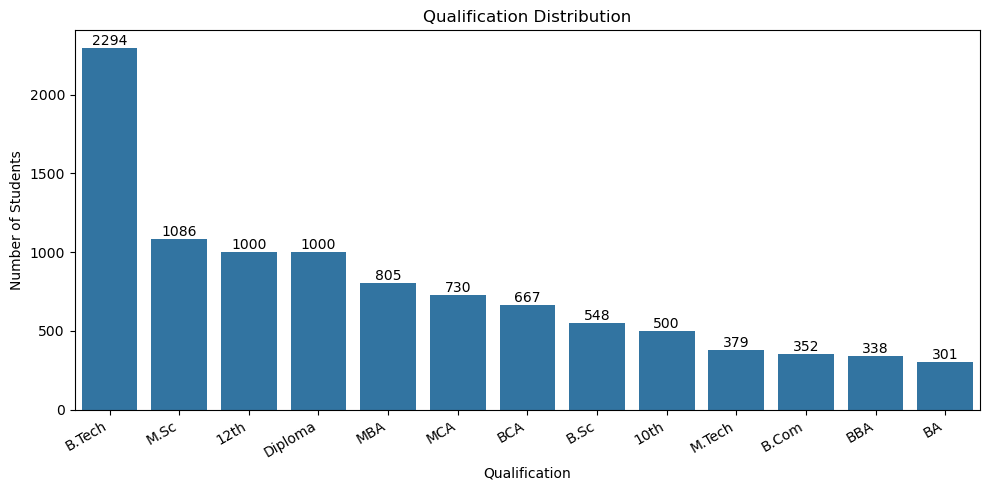

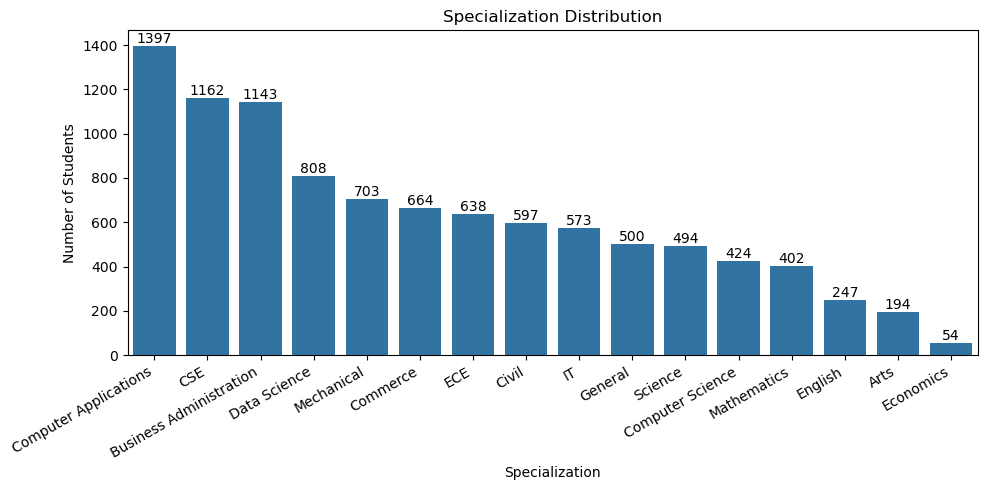

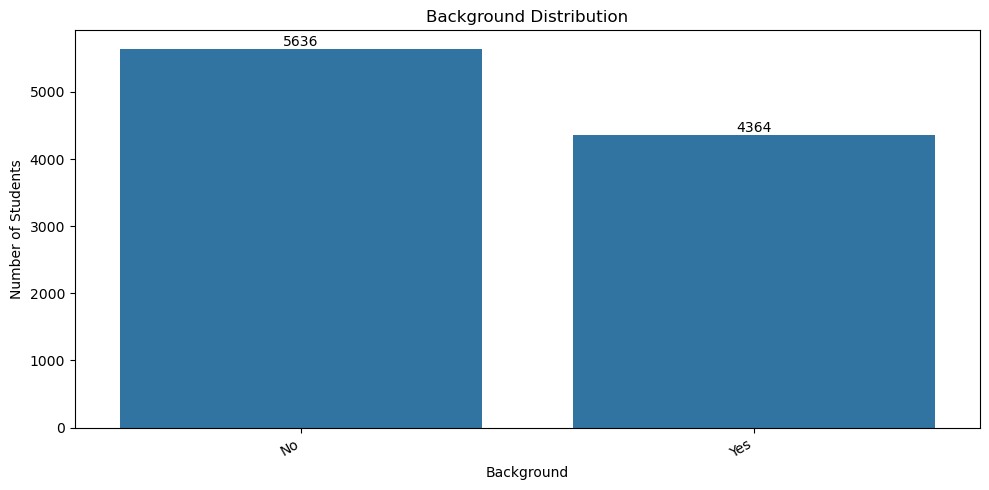

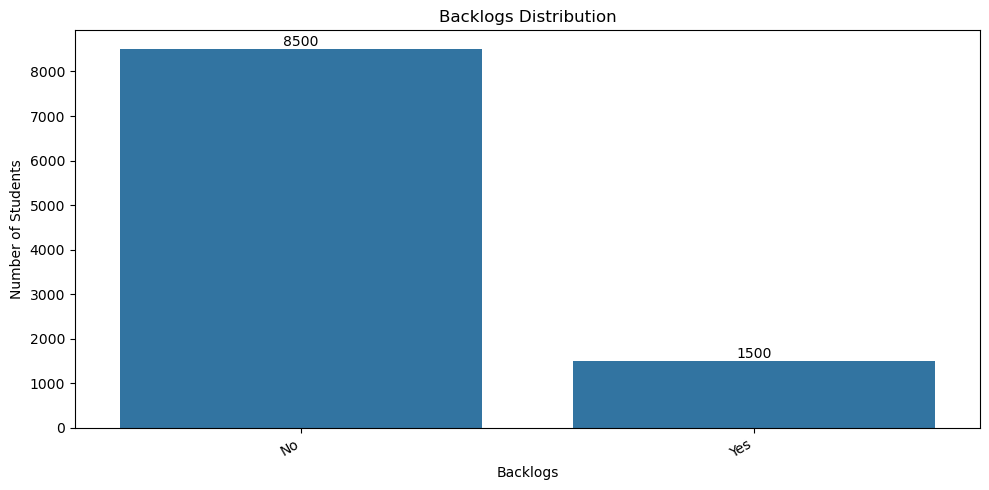

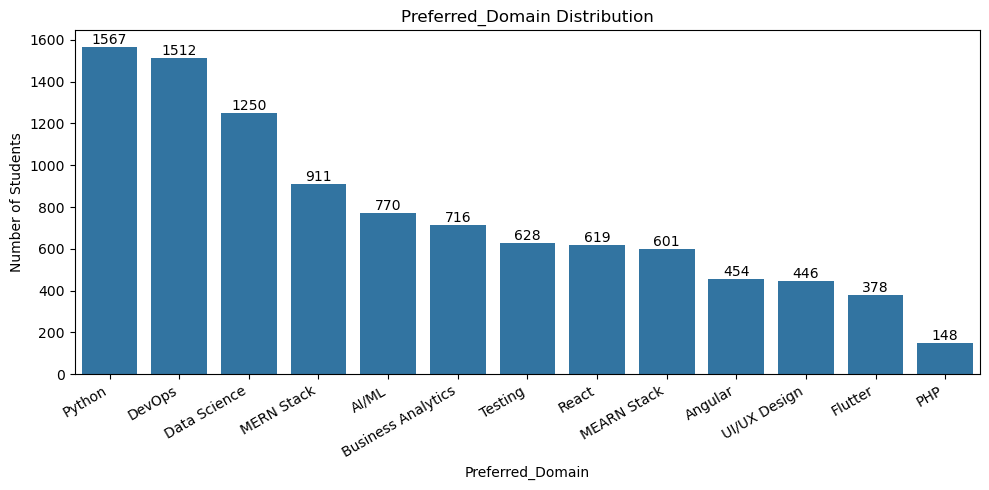

In [14]:
student_plot("gender")
student_plot("education_level")
student_plot("qualification")
student_plot("specialization")
student_plot("background")
student_plot("backlogs")
student_plot("preferred_domain")

In [15]:
students_df["preferred_domain"] = students_df["preferred_domain"].replace({"MEARN Stack":"MERN Stack"})

leftover = set(students_df["preferred_domain"].unique()) - set(courses_df['category'].unique())
print(leftover)

set()


In [16]:
skill_rename_map = {
    'REST API': 'REST APIs',       
    'Bug Tracking': 'Bug Reporting',
    'UX Research': 'User Research',  
    'MySQL': 'SQL'            
}
courses_df['skills_list'] = courses_df['skills_taught'].apply(
    lambda s: [skill_rename_map.get(x.strip(), x.strip()) for x in s.split(',')]
)

### Building the Recommendation system

In [17]:
# mapping the question to courses category
category_to_question = {
    'Python': 'Q2', 
    'MERN Stack': 'Q2', 
    'React': 'Q2', 
    'Angular': 'Q2', 
    'PHP': 'Q2',
    
    'Flutter': 'Q3', 
    'AI/ML': 'Q4',
    
    'Data Science': 'Q5', 
    'Business Analytics': 'Q5',
    
    'DevOps': 'Q6',
    #'Cyber Security': 'Q7', 
    'UI/UX Design': 'Q8', 
    'Testing': 'Q9'
}

# merging the studnets answers to student profile 
profile_df = students_df.merge(answers_df,on="student_id")

# creating a dictionary that maps students id to their skill and experience
skills_lookup = (
    skills_df.groupby("student_id").apply(lambda d: dict(zip(d['skill'],d['experience_level']))).to_dict()
)

# creating another column in courses
courses_df['skills_list'] = courses_df['skills_taught'].apply(lambda s: [x.strip() for x in s.split(',')])

In [18]:
category_to_question

{'Python': 'Q2',
 'MERN Stack': 'Q2',
 'React': 'Q2',
 'Angular': 'Q2',
 'PHP': 'Q2',
 'Flutter': 'Q3',
 'AI/ML': 'Q4',
 'Data Science': 'Q5',
 'Business Analytics': 'Q5',
 'DevOps': 'Q6',
 'UI/UX Design': 'Q8',
 'Testing': 'Q9'}

In [19]:
print(skills_lookup['STU00001'])
print(courses_df['skills_list'].iloc[0])

{'Business Communication': 2, 'Git': 2, 'MS Office': 2, 'Python': 2}
['Python', 'Django', 'HTML', 'CSS', 'JavaScript', 'MySQL', 'REST API', 'Git']


##### Building Studnet Profiles

In [20]:
def build_student_profile(student_id):
    """
    Builds a complete student profile by combining
    student information, questionnaire answers, and skills.
    """

    # get students row
    student_row = profile_df[profile_df["student_id"] == student_id]

    if student_row.empty:
        raise ValueError(f"Student ID {student_id} not found.")

    student_row = student_row.iloc[0]

    # students skills
    student_skills = skills_lookup.get(student_id, {})

    # questionare answers
    quest_col = [col for col in profile_df.columns if col.startswith("Q")]

    answers = {question:int(student_row[question])for question in quest_col}

    # Building the profile
    student_profile = {

        "student_info":{
            
            "student_id":student_row["student_id"],
            "name": student_row["name"],
            "age": int(student_row["age"]),
            "gender": student_row["gender"],
            "education_level": student_row["education_level"],
            "qualification": student_row["qualification"],
            "specialization": student_row["specialization"],
            "background": student_row["background"],
            "cgpa": float(student_row["cgpa"]),
            "backlogs": student_row["backlogs"],
            "preferred_domain": student_row["preferred_domain"]
        },

        "skills":student_skills,

        "answers":answers
    }

    return student_profile

In [21]:
student = build_student_profile("STU00001")
student

{'student_info': {'student_id': 'STU00001',
  'name': 'Anika Seth',
  'age': 22,
  'gender': 'Female',
  'education_level': 'Undergraduate',
  'qualification': 'B.Tech',
  'specialization': 'ECE',
  'background': 'No',
  'cgpa': 7.91,
  'backlogs': 'No',
  'preferred_domain': 'Testing'},
 'skills': {'Business Communication': 2,
  'Git': 2,
  'MS Office': 2,
  'Python': 2},
 'answers': {'Q1': 3,
  'Q2': 1,
  'Q3': 2,
  'Q4': 3,
  'Q5': 1,
  'Q6': 2,
  'Q7': 2,
  'Q8': 1,
  'Q9': 4,
  'Q10': 5}}

##### Building Course Profiles

In [22]:
def build_course_profile(course_row):
    """
    Building a profile for a single course
    """
    course_profile = {

        "course_info":
        {
            "course_id":course_row["course_id"],
            "course_name": course_row["course_name"],
            "category": course_row["category"],
            "description": course_row["course_description"],
            "certification": course_row["certification"],
            "placement_support": course_row["placement_support"],
            "roadmap": course_row["roadmap"],
            "course_url": course_row["course_url"]
        },

        "skills": course_row["skills_list"]

    }

    return course_profile

In [23]:
course = build_course_profile(courses_df.iloc[10])
course

{'course_info': {'course_id': 'C011',
  'course_name': 'Software Testing',
  'category': 'Testing',
  'description': 'Learn manual and automation testing techniques.',
  'certification': 'Yes',
  'placement_support': 'Yes',
  'roadmap': 'Testing Basics → Manual Testing → Selenium → Automation',
  'course_url': 'https://cybersquare.pro/'},
 'skills': ['Manual Testing', 'Selenium', 'TestNG', 'Bug Tracking']}

##### Calculate Interest Score

In [24]:
def calculate_interest_score(student_profile,course_category):
    """
    Calculate the student's interest score for a course.

    Every course is mapped to one questionnaire question that measures
    the student's interest in that field. This function retrieves the
    student's answer and converts it into a score out of 100.

    Parameters:
        student_profile (dict): Student's questionnaire responses.
        course_category (str): Category of the course.

    Returns:
        float: Interest score between 0 and 100.
    """
    
    # get the students answers 
    student_answer = student_profile["answers"]

    # question mapped to the course category
    question = category_to_question.get(course_category)

    if question is None:
        return 0

    
    # students rating to mapped question
    rating = student_answer.get(question,0)

    # rating scale in range of 1-100
    intrest_score = (rating/5) * 100
    
    return round(intrest_score,2)

In [25]:
interest_score = calculate_interest_score(
    student,
    "Testing"
)

print(f"Interest Score: {interest_score}")

Interest Score: 80.0


##### Calaculate Skill Score

In [26]:
def calculate_skill_score(student_profile,course_profile):
    """
    Calculate the student's skill score for a course.

    This function compares the student's existing skills with the
    skills required for the course. Only skills selected and rated
    by the student are considered in the calculation. Missing skills
    are ignored rather than treated as zero.
    
    Parameters:
        student_profile (dict):
            Student profile generated using build_student_profile().

        course_profile (dict):
            Course profile generated using build_course_profile().

    Returns:
        float:
            Skill score between 0 and 100.
    """

    # get students skill
    student_skills = student_profile["skills"]

    # get course skills
    course_skills = course_profile["skills"]
    
    matched_levels = [student_skills[skill] for skill in course_skills if skill in student_skills]

    # If the student has none of the required skills
    if not matched_levels:
        return 0
        
        
    # calculate the avg skill level
    average_skill = sum(matched_levels)/len(matched_levels)

    # convert the average skill level into a score out of 100
    skill_score = (average_skill/5)*100

    return round(skill_score, 2)



In [27]:
skill_score = calculate_skill_score(student,course)
print()
print(f"Skill score: {skill_score}")


Skill score: 0


##### Calculate Programming Score

In [28]:
PROGRAMMING_QUESTION = "Q1"

def calculate_programming_scores(student_profile):
    """
    Calculate the Programming knowledge score for a student.

    Parameters:
        student_profile (dict): Dictionary containing student information,
        skills, and questionnaire responses.

    Returns:
        float: Programming Knowledge Score (0–100)
    """
    # get the students response
    answer = student_profile["answers"]

    # get the rating for Q1
    rating = answer.get(PROGRAMMING_QUESTION)

    # converting to score out of 100
    score = (rating/5) * 100

    return score

In [29]:
score = calculate_programming_scores(student)

print(f"\nReturned Score: {score}")


Returned Score: 60.0


#####  Learning Commitment Score

In [30]:
LEARNING_QUESTION = "Q10"

def calculate_learning_score(student_profile):
    """
    Calculates the learning commitment score for a student.

    Parameters:
        student_profile (dict): Using build_student_profile().

    Returns:
        float:Learning Commitment Score (0–100).
    """

    # get the students response
    answer = student_profile["answers"]

    # get the rating for Q10
    rating = answer.get(LEARNING_QUESTION)

    # convert to a score out of 100
    score = (rating/5)*100

    return score


In [31]:
learning_score = calculate_learning_score(student)
print(f"\nReturned Score: {learning_score}")



Returned Score: 100.0


### Recommendation Score Configuration

The core recommendation score considers the students course interest,existing skill match,programming knowledge,and learning commitment.

Since the courses can also be taken by beginners, existing skills are considered useful but are given a lower influence than interest, programming foundation, and commitment  to learning.

A small score is also given to students with an IT background to represent prior exposure to technology.

The students preferred domain is handled separately during course ranking. It acts as a preference when course scores are close rather than automatically overriding stronger course matches.

In [32]:
# weights
INTEREST_WEIGHT = 0.35
SKILL_WEIGHT = 0.15
PROGRAMMING_WEIGHT = 0.25
LEARNING_WEIGHT = 0.25

# score difference where preferred domain can influence ranking
PREFERRED_DOMAIN_MARGIN = 5

### Calculate Final Recommendation Score

The Final recommendation score combines the different factors used to measure how suitable a particular course is for a student.


In [33]:
def calculate_final_score(student_profile,course_profile):
    """
    Calculate the final recommendation score

    This function combines the students interest,skill match,
    programming knowledge score and learning commintment using the configured weights 
    variable

    parameters:
        students profile(dict) : students profile build using student_profile() function

        course_profile(dict) : course profile build using course_profile() function

    Returns:
        float: Final recommendation score between 0-100
        
    """

    # find the individual scores 
    interest_score = calculate_interest_score(student_profile,course_profile["course_info"]["category"])

    skill_score = calculate_skill_score(student_profile,course_profile)

    programming_score = calculate_programming_scores(student_profile)

    learning_score = calculate_learning_score(student_profile)

    # calculate the weighted score
    weighted_score = (
        interest_score * INTEREST_WEIGHT +
        skill_score * SKILL_WEIGHT +
        programming_score * PROGRAMMING_WEIGHT +
        learning_score * LEARNING_WEIGHT
    )


    # calculating the final score
    final_score = weighted_score

    # prevent from going over 100
    final_score = min(final_score,100)

    return round(final_score,2)

In [34]:
final_score = calculate_final_score(student,course)

print("Final Recommendation Score")
print("--------------------------\n")
print(f"{('Student ID'):15}: {student["student_info"]["student_id"]}")
print(f"{('Course'):15}: {course["course_info"]["course_name"]}")
print(f"{('Final Score'):15}: {final_score}/100")

Final Recommendation Score
--------------------------

Student ID     : STU00001
Course         : Software Testing
Final Score    : 68.0/100


### Score For All Course

In [35]:
def score_all_course(student_profile,course_df):
    """
    Calculate recommendation scores for all available courses.

    Each course is evaluated against the same student profile. 
    The courses are then ranked from the highest recommendation score to the lowest.

    Parameters:
        student_profile (dict):Student profile created using build_student_profile().

        courses_df (DataFrame):DataFrame containing all available courses.

    Returns:
        DataFrame:All courses ranked by their final recommendation score.
    """

    # store the result scores
    course_scores = []

    #loop through every course in dataset
    for _, course_row in courses_df.iterrows():
        course_profile = build_course_profile(course_row)
        
        # calculate the final score
        final_score = calculate_final_score(student_profile,course_profile)
        
        # store the result
        course_scores.append(
            {
                "course_id":course_profile["course_info"]["course_id"],
                "course_name":course_profile["course_info"]["course_name"],
                "category":course_profile["course_info"]["category"],
                "final_score":final_score
            })
    # converting the results to a DataFrame
    ranking_df = pd.DataFrame(course_scores)

    # Rank courses from highest score to lowest
    ranking_df = ranking_df.sort_values(by="final_score",ascending=False).reset_index(drop=True)

    return ranking_df
    
        

In [36]:
course_rank = score_all_course(student,courses_df)

course_rank

,course_id,course_name,category,final_score
0,C011,Software Testing,Testing,68.0
1,C008,Artificial Intelligence with Python,AI/ML,67.0
2,C010,DevOps,DevOps,60.0
3,C003,Flutter Development,Flutter,54.0
4,C001,Python Full Stack Development,Python,53.0
5,C002,MERN Stack Development,MERN Stack,53.0
6,C007,Data Science with Python,Data Science,53.0
7,C004,React Front End Development,React,47.0
8,C005,Angular Development,Angular,47.0
9,C006,PHP Full Stack Development,PHP,47.0


### Apply Preferred Domain Preference

In [37]:
def apply_preferred_domain(ranking_df,student_profile):
    """
    Apply the student's preferred domain to close course recommendations.

    If the preferred domain course is within the configured margin
    of the highest scoring course, it is promoted to the first position.
    The actual recommendation scores are not changed.

    Parameters:
        ranking_df (DataFrame):Courses ranked by their recommendation scores.

        student_profile (dict):Student profile containing the preferred domain.

    Returns:
        DataFrame:Final course ranking after considering preferred domain.
    """

    # creating a copy.-
    final_ranking = ranking_df.copy()

    # students preferred domain
    preferred_domain = student_profile["student_info"]["preferred_domain"]

    # find the course that belongs to preferred domain
    preferred_course = final_ranking[final_ranking["category"]==preferred_domain]

    if preferred_course.empty:
        return final_ranking
    
    # get the top score and preferred domain score
    top_score = final_ranking.iloc[0]["final_score"]
    preferred_score = preferred_course.iloc[0]["final_score"]
    
    # get the preferred course index
    preferred_index = preferred_course.index[0]
    
    # check the difference in score
    score_diff = top_score - preferred_score

    if score_diff <= PREFERRED_DOMAIN_MARGIN:
        preferred_row = final_ranking.loc[[preferred_index]]
        remaining_rows = final_ranking.drop(preferred_index)

        final_ranking = pd.concat([preferred_row,remaining_rows],ignore_index=True)

    return final_ranking
    

### Generate The Top 3 Course Recommendations

In [38]:
def recommend_courses(student_id,course_df,top_n=3):
    """
    Generate the top course recommendations for a student.

    The function builds the students profile, calculates the
    recommendation score for every course, applies the preferred
    domain rule, and returns the highest ranked courses.

    Parameters:
    
        student_id (str): ID of the student.

        courses_df (DataFrame): DataFrame containing all available courses.

        top_n (int): Number of course recommendations to return.
                     Default is 3.

    Returns:
        DataFrame: Top recommended courses for the student.
    """

    # build student profile
    students_profile = build_student_profile(student_id)

    # calculate the scores for all courses
    course_ranking = score_all_course(students_profile,course_df)

    # appplying preferred domain score
    final_ranking = apply_preferred_domain(course_ranking,students_profile)

    # select the top courses
    recommendations = final_ranking.head(top_n).copy()

    # check whether each course matches the students preferred domain
    preferred_domain = students_profile["student_info"]["preferred_domain"]

    recommendations["preferred_domain_match"] = (recommendations["category"]==preferred_domain).map({True:"Yes",False:"No"})

    # create recommendation rank
    # DataFrame.insert(position,column_name,values)
    recommendations.insert(0,"rank",range(1,len(recommendations) +1))

    return recommendations

In [39]:
recommendations = recommend_courses("STU00003",courses_df)

recommendations

,rank,course_id,course_name,category,final_score,preferred_domain_match
0,1,C001,Python Full Stack Development,Python,99.0,Yes
1,2,C010,DevOps,DevOps,100.0,No
2,3,C002,MERN Stack Development,MERN Stack,98.5,No


### Validate The Recommendation Logic

In [40]:
def validate_recommendations(student_ids,course_df):
    """
    Generate a summary of the Top 3 course recommendations
    for multiple students.

    Parameters:
        student_ids (list): List of student IDs to evaluate.

        courses_df (DataFrame): DataFrame containing available courses.

    Returns:
        DataFrame: Summary of recommendations for each student.
    """
    validation_results =[]

    for id in student_ids:

        student_profile = build_student_profile(id)

        recommendations = recommend_courses(id,course_df)

        validation_results.append({
            "student_id":id,
            "preferred_domain":student_profile["student_info"]["preferred_domain"],

            "recommendation_1":recommendations.iloc[0]["course_name"],
            "score_1" : recommendations.iloc[0]["final_score"],

            "recommendation_2":recommendations.iloc[1]["course_name"],
            "score_2" : recommendations.iloc[1]["final_score"],

            "recommendation_3":recommendations.iloc[2]["course_name"],
            "score_3" : recommendations.iloc[2]["final_score"],
        })

    validation_df = pd.DataFrame(validation_results)

    return validation_df


In [41]:
student_ids = students_df["student_id"].to_list()

validation_df = validate_recommendations(student_ids,courses_df)

validation_df

,student_id,preferred_domain,recommendation_1,score_1,recommendation_2,score_2,recommendation_3,score_3
0,STU00001,Testing,Software Testing,68.0,Artificial Intelligence with Python,67.0,DevOps,60.0
1,STU00002,React,React Front End Development,63.0,Python Full Stack Development,63.0,MERN Stack Development,63.0
2,STU00003,Python,Python Full Stack Development,99.0,DevOps,100.0,MERN Stack Development,98.5
3,STU00004,Data Science,Business Analytics,92.0,Data Science with Python,80.0,Artificial Intelligence with Python,80.0
4,STU00005,Testing,Software Testing,53.0,Business Analytics,50.5,Data Science with Python,46.0
...,...,...,...,...,...,...,...,...
9995,STU09996,Business Analytics,Business Analytics,53.0,Data Science with Python,53.0,Python Full Stack Development,39.0
9996,STU09997,DevOps,DevOps,48.0,Business Analytics,44.0,Data Science with Python,41.0
9997,STU09998,Python,Artificial Intelligence with Python,80.0,Data Science with Python,73.0,Business Analytics,70.0
9998,STU09999,Python,Artificial Intelligence with Python,100.0,DevOps,88.5,Data Science with Python,79.0


In [42]:
recommendation_distribution = (
    validation_df["recommendation_1"].value_counts().reset_index()
)

recommendation_distribution

,recommendation_1,count
0,DevOps,1706
1,Business Analytics,1570
2,MERN Stack Development,1363
3,Python Full Stack Development,1134
4,Artificial Intelligence with Python,983
5,Data Science with Python,967
6,Software Testing,554
7,React Front End Development,531
8,UI/UX Design,411
9,Flutter Development,331


In [43]:
recommendation_distribution["percentage"] = (recommendation_distribution["count"]/ len(validation_df)* 100).round(2)

recommendation_distribution

,recommendation_1,count,percentage
0,DevOps,1706,17.06
1,Business Analytics,1570,15.70
2,MERN Stack Development,1363,13.63
3,Python Full Stack Development,1134,11.34
4,Artificial Intelligence with Python,983,9.83
5,Data Science with Python,967,9.67
6,Software Testing,554,5.54
7,React Front End Development,531,5.31
8,UI/UX Design,411,4.11
9,Flutter Development,331,3.31


In [44]:
answers_df["Q7"].value_counts().sort_index()

Q7
1    3491
2    6509
Name: count, dtype: int64

In [45]:
result = validation_df.loc[validation_df['recommendation_1'] == 'Cyber Security']
result

,student_id,preferred_domain,recommendation_1,score_1,recommendation_2,score_2,recommendation_3,score_3


In [46]:
a = build_student_profile("STU09200")
a

{'student_info': {'student_id': 'STU09200',
  'name': 'Dalaja Naik',
  'age': 24,
  'gender': 'Female',
  'education_level': 'Working Professional',
  'qualification': 'M.Sc',
  'specialization': 'Computer Science',
  'background': 'Yes',
  'cgpa': 5.5,
  'backlogs': 'Yes',
  'preferred_domain': 'Python'},
 'skills': {'Programming Fundamentals': 4,
  'Algorithms': 3,
  'Data Visualization': 2,
  'MS Office': 2,
  'Django': 1,
  'Linux': 1,
  'NumPy': 1},
 'answers': {'Q1': 4,
  'Q2': 1,
  'Q3': 2,
  'Q4': 2,
  'Q5': 2,
  'Q6': 2,
  'Q7': 2,
  'Q8': 1,
  'Q9': 2,
  'Q10': 2}}

### ML

In [47]:
skills_df["skill"].nunique()

72

In [48]:
# students_info
student_features_df = students_df[[
    "student_id",
    "age",
    "education_level",
    "qualification",
    "background",
    "cgpa",
    "backlogs",
    "preferred_domain"
]].copy()

# skills feature
skill_features_df = skills_df.pivot_table(index="student_id",columns="skill",values="experience_level",fill_value=0).reset_index()

# answers to questions
questionare_features_df = answers_df[[
    "student_id",
    "Q1",
    "Q2",
    "Q3",
    "Q4",
    "Q5",
    "Q6",
    "Q8",
    "Q9",
    "Q10"   
]].copy()


display(student_features_df.head())
display(skill_features_df.head())
display(questionare_features_df.head())

,student_id,age,education_level,qualification,background,cgpa,backlogs,preferred_domain
0,STU00001,22,Undergraduate,B.Tech,No,7.91,No,Testing
1,STU00002,22,Undergraduate,B.Tech,Yes,6.51,No,React
2,STU00003,30,Working Professional,M.Sc,Yes,8.77,No,Python
3,STU00004,30,Working Professional,MBA,No,8.69,No,Data Science
4,STU00005,19,12th,12th,No,7.46,No,Testing


skill,student_id,API Testing,AWS,Algorithms,Analytical Thinking,Angular,AutoCAD Basics,Automation Basics,Azure,Bug Reporting,...,SQL,Shell Scripting,Statistics,Test Cases,Testing Basics,TypeScript,UI Design,User Research,Visual Design,Wireframing
0,STU00001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,STU00002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,STU00003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,STU00004,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0
4,STU00005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,student_id,Q1,Q2,Q3,Q4,Q5,Q6,Q8,Q9,Q10
0,STU00001,3,1,2,3,1,2,1,4,5
1,STU00002,4,4,1,2,2,4,2,2,3
2,STU00003,5,5,2,5,4,5,2,2,5
3,STU00004,4,2,3,5,5,2,3,2,5
4,STU00005,2,2,1,2,3,2,2,4,3


### Combine Features for the Machine Learning Dataset

In [49]:
ml_features_df = student_features_df.merge(questionare_features_df,on="student_id",how="inner")

ml_features_df = ml_features_df.merge(skill_features_df,on="student_id",how="inner")

ml_features_df.head()

,student_id,age,education_level,qualification,background,cgpa,backlogs,preferred_domain,Q1,Q2,...,SQL,Shell Scripting,Statistics,Test Cases,Testing Basics,TypeScript,UI Design,User Research,Visual Design,Wireframing
0,STU00001,22,Undergraduate,B.Tech,No,7.91,No,Testing,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,STU00002,22,Undergraduate,B.Tech,Yes,6.51,No,React,4,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,STU00003,30,Working Professional,M.Sc,Yes,8.77,No,Python,5,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,STU00004,30,Working Professional,MBA,No,8.69,No,Data Science,4,2,...,4.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0
4,STU00005,19,12th,12th,No,7.46,No,Testing,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
ml_features_df.shape

(10000, 89)

### Creating Target Feature

In [51]:
target_df = validation_df[["student_id","recommendation_1"]].copy()

target_df = target_df.rename(columns={"recommendation_1":"recommended_course"})

target_df.head()

,student_id,recommended_course
0,STU00001,Software Testing
1,STU00002,React Front End Development
2,STU00003,Python Full Stack Development
3,STU00004,Business Analytics
4,STU00005,Software Testing


In [52]:
target_df["student_id"].nunique()

10000

In [53]:
training_df = ml_features_df.merge(target_df,on="student_id",how="inner")

training_df.head()

,student_id,age,education_level,qualification,background,cgpa,backlogs,preferred_domain,Q1,Q2,...,Shell Scripting,Statistics,Test Cases,Testing Basics,TypeScript,UI Design,User Research,Visual Design,Wireframing,recommended_course
0,STU00001,22,Undergraduate,B.Tech,No,7.91,No,Testing,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Software Testing
1,STU00002,22,Undergraduate,B.Tech,Yes,6.51,No,React,4,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,React Front End Development
2,STU00003,30,Working Professional,M.Sc,Yes,8.77,No,Python,5,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Python Full Stack Development
3,STU00004,30,Working Professional,MBA,No,8.69,No,Data Science,4,2,...,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,Business Analytics
4,STU00005,19,12th,12th,No,7.46,No,Testing,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Software Testing


#### Validating Training Data

In [54]:
print(training_df.shape)

print(training_df["student_id"].nunique())

print(training_df.duplicated().sum())

print(training_df.isna().sum())

(10000, 90)
10000
0
student_id            0
age                   0
education_level       0
qualification         0
background            0
                     ..
UI Design             0
User Research         0
Visual Design         0
Wireframing           0
recommended_course    0
Length: 90, dtype: int64


In [55]:
training_df.dtypes.value_counts()

float64    73
int64      10
object      7
Name: count, dtype: int64

In [56]:
target_distribution = (training_df["recommended_course"].value_counts().reset_index())

target_distribution

,recommended_course,count
0,DevOps,1706
1,Business Analytics,1570
2,MERN Stack Development,1363
3,Python Full Stack Development,1134
4,Artificial Intelligence with Python,983
5,Data Science with Python,967
6,Software Testing,554
7,React Front End Development,531
8,UI/UX Design,411
9,Flutter Development,331


#### Prepare Features and Target for Machine Learning

In [57]:
X = training_df.drop(columns=["student_id","recommended_course"])

y = training_df["recommended_course"]

In [58]:
print(X.shape)
print(y.shape)

(10000, 88)
(10000,)


#### Training and Testing Sets

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [61]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((8000, 88), (2000, 88), (8000,), (2000,))

In [62]:
# seperating categorical and numerical columns 
categorical_columns = X_train.select_dtypes(include="object").columns.tolist()

numerical_columns = X_train.select_dtypes(include="number").columns.tolist()

In [63]:
print(len(categorical_columns))
print(len(numerical_columns))

5
83


#### Encoding

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [65]:
onehot_encoder = OneHotEncoder(
    handle_unknown = "ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
                ("categorical",onehot_encoder,categorical_columns),
                ("numerical","passthrough",numerical_columns)
                ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [66]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nAfter preprocessing:")
print("X_train:", X_train_processed.shape)
print("X_test :", X_test_processed.shape)

X_train: (8000, 88)
X_test : (2000, 88)

After preprocessing:
X_train: (8000, 118)
X_test : (2000, 118)


In [67]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['categorical__education_level_10th',
       'categorical__education_level_12th',
       'categorical__education_level_Diploma',
       'categorical__education_level_Postgraduate',
       'categorical__education_level_Undergraduate',
       'categorical__education_level_Working Professional',
       'categorical__qualification_10th',
       'categorical__qualification_12th',
       'categorical__qualification_B.Com',
       'categorical__qualification_B.Sc',
       'categorical__qualification_B.Tech',
       'categorical__qualification_BA', 'categorical__qualification_BBA',
       'categorical__qualification_BCA',
       'categorical__qualification_Diploma',
       'categorical__qualification_M.Sc',
       'categorical__qualification_M.Tech',
       'categorical__qualification_MBA', 'categorical__qualification_MCA',
       'categorical__background_No', 'categorical__background_Yes',
       'categorical__backlogs_No', 'categorical__backlogs_Yes',
       'categorical__preferred_dom

In [68]:
X_train_processed = pd.DataFrame(X_train_processed,columns=feature_names,index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed,columns=feature_names,index = X_test.index)

### Model Training

Multiple classification algorithms are evaluated to determine which model performs best for the course recommendation task.


#### Logistic Regression

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [70]:
logistic_param_grid = [
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    }]

In [71]:
logistic_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000
    ),
    param_grid=logistic_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

In [72]:
logistic_grid.fit(X_train_processed,y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"[{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l2'], 'solver': ['lbfgs']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [73]:
print("Best parameters: \n",logistic_grid.best_params_)
print("Best Cross validation Macro F1: \n",logistic_grid.best_score_)

Best parameters: 
 {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross validation Macro F1: 
 0.912150434069102


In [74]:
logistic_model = logistic_grid.best_estimator_

In [75]:
y_pred_logistic = logistic_model.predict(X_test_processed)

#### Accuracy

In [76]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import f1_score

In [77]:
logistic_accuracy = accuracy_score(y_test,y_pred_logistic)
class_report = classification_report(y_test,y_pred_logistic)
cm = confusion_matrix(y_test,y_pred_logistic)
logistic_f1 = f1_score(y_test,y_pred_logistic,average="macro")

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Macro F1: {logistic_f1:.4f}")

Logistic Regression Accuracy: 0.9005
Macro F1: 0.9082


In [78]:
print("classification report: \n",class_report)

classification report: 
                                      precision    recall  f1-score   support

                Angular Development       0.88      0.94      0.91        65
Artificial Intelligence with Python       0.92      0.94      0.93       197
                 Business Analytics       0.93      0.92      0.93       314
           Data Science with Python       0.88      0.91      0.90       193
                             DevOps       0.96      0.95      0.95       341
                Flutter Development       0.97      0.91      0.94        66
             MERN Stack Development       0.84      0.87      0.85       273
         PHP Full Stack Development       0.86      0.96      0.91        25
      Python Full Stack Development       0.76      0.70      0.73       227
        React Front End Development       0.93      0.94      0.93       106
                   Software Testing       0.95      0.95      0.95       111
                       UI/UX Design       0.98    

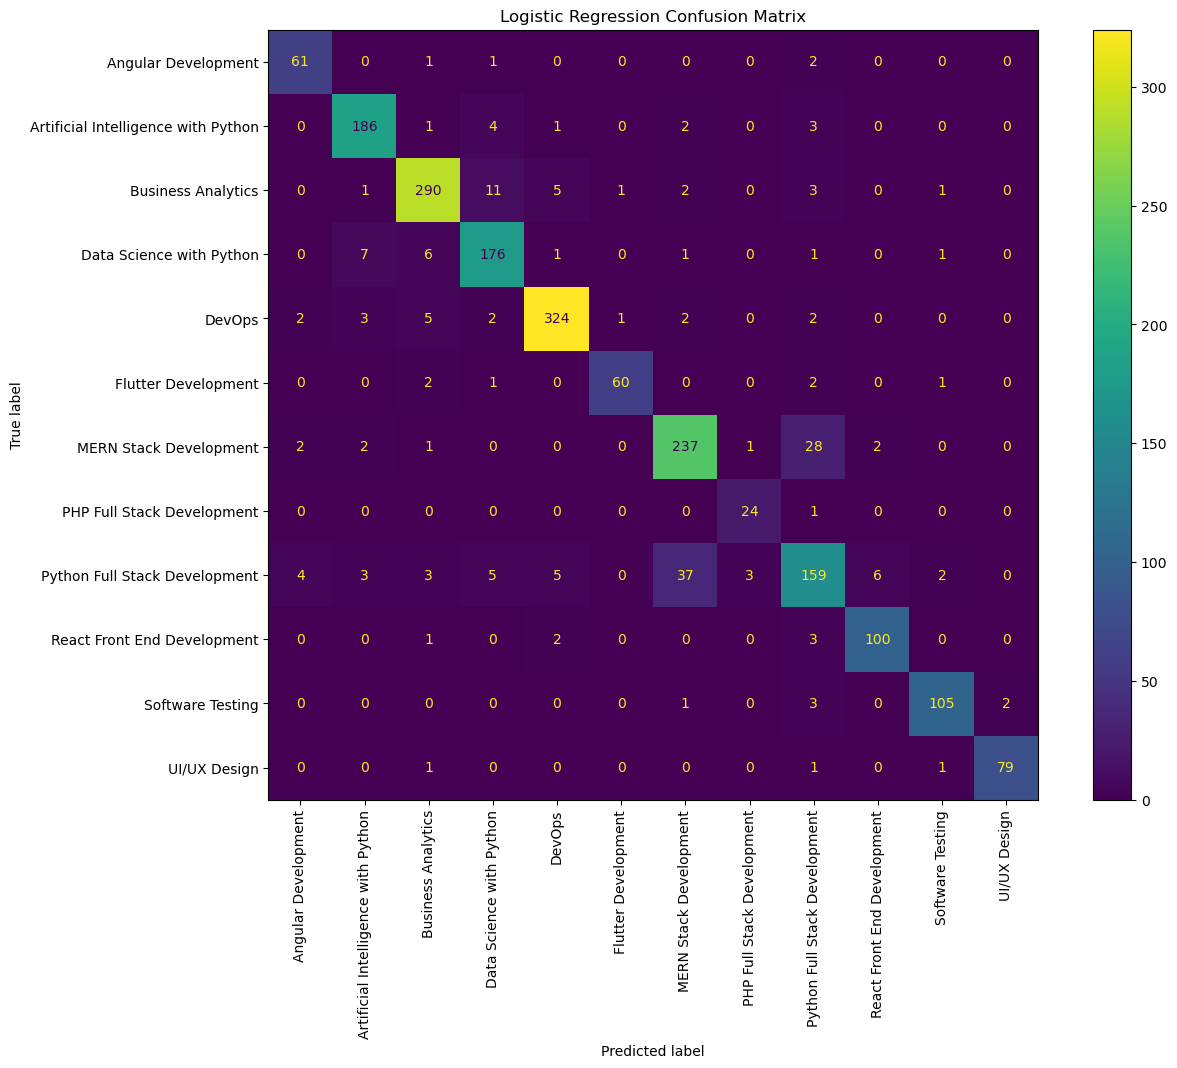

In [79]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=logistic_model.classes_)
fig, ax = plt.subplots(figsize=(14, 10))
disp.plot(ax=ax,xticks_rotation=90)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [80]:
# Testing on Trainig data
logistic_train_accuracy = accuracy_score(y_train,logistic_model.predict(X_train_processed))

print(f"logistic regression training accuracy: {logistic_train_accuracy*100}")
print(f"logistic regression test accuracy: {logistic_accuracy*100}")

logistic regression training accuracy: 94.35
logistic regression test accuracy: 90.05


he Logistic Regression model achieved a training accuracy of **94.35%** and a test accuracy of **90.05%**.

The **4.30 percentage-point gap** between training and test accuracy indicates a small amount of overfitting. However, the relatively close performance suggests that the model generalizes reasonably well to unseen data.

#### Feature Importance

In [81]:
feature_importance = pd.DataFrame({
    "Features":X_train_processed.columns,
    "Importance":np.mean(np.abs(logistic_model.coef_),axis=0)
})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(10)

,Features,Importance
38,numerical__Q2,4.603149
41,numerical__Q5,2.491187
24,categorical__preferred_domain_Angular,1.834141
30,categorical__preferred_domain_PHP,1.707522
40,numerical__Q4,1.697544
32,categorical__preferred_domain_React,1.642174
42,numerical__Q6,1.542593
44,numerical__Q9,1.531191
43,numerical__Q8,1.509941
39,numerical__Q3,1.422379


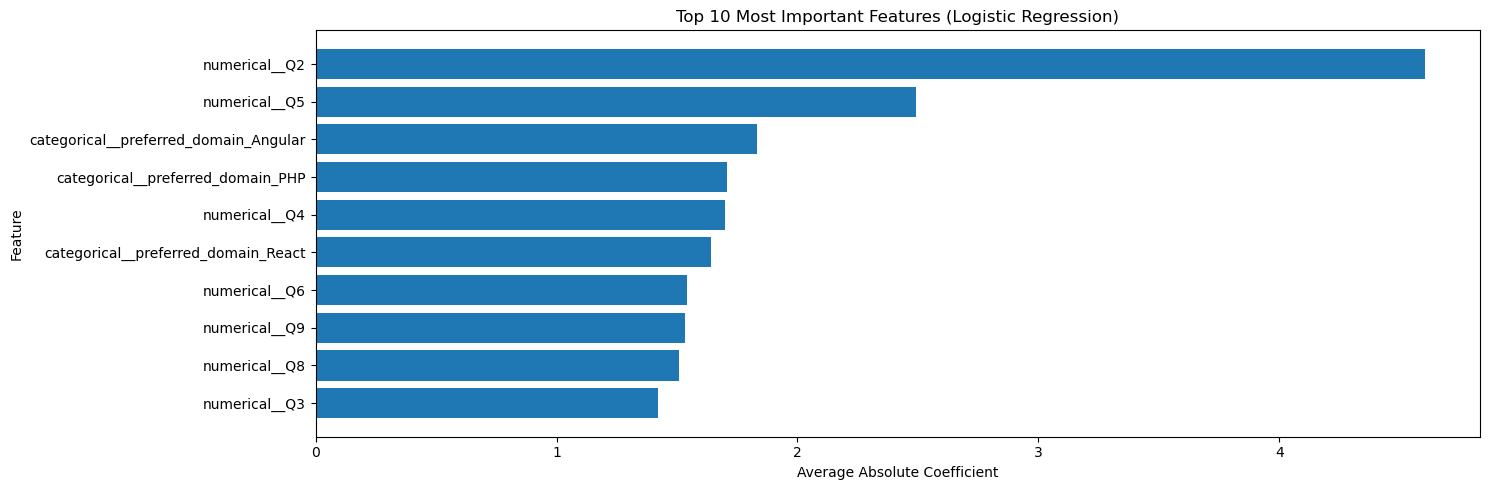

In [82]:
top_features = feature_importance.head(10)

plt.figure(figsize=(15,5))

plt.barh(
    top_features["Features"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Most Important Features (Logistic Regression)")
plt.xlabel("Average Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

#### Decision Tree Classifier

A Decision Tree classifier is trained as the second model.

Unlike Logistic Regression, a Decision Tree can learn nonlinear relationships by repeatedly splitting the data based on feature values. This makes it suitable for capturing rule-based patterns within the course recommendation dataset.

In [83]:
from sklearn.tree import DecisionTreeClassifier

In [84]:
decision_param_grid = {
    "criterion":["gini","entropy"],
    "max_depth":[10,15,20,25,30,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "class_weight":[None,"balanced"]
}

decision_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=decision_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

decision_grid.fit(X_train_processed,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [85]:
print("Best Parameters: \n",decision_grid.best_params_)
print("Best Macro F1: \n",decision_grid.best_score_)

Best Parameters: 
 {'class_weight': None, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Macro F1: 
 0.9129328501884626


In [86]:
decision_model = decision_grid.best_estimator_

In [87]:
y_pred_decision = decision_model.predict(X_test_processed)

In [88]:
print(decision_model.get_depth())
print(decision_model.get_n_leaves())

20
583


#### Model Evaluation

In [89]:
decision_accuracy = accuracy_score(y_test,y_pred_decision)
class_report_decison = classification_report(y_test,y_pred_decision)
cm_decision = confusion_matrix(y_test,y_pred_decision)
decision_f1 = f1_score(y_test,y_pred_decision,average="macro")

print(f"Decision tree Accuracy: {decision_accuracy:.3f}")
print(f"Decision Tree F1: {decision_f1:.3f}")
print(f"classification report: \n{class_report_decison}")

Decision tree Accuracy: 0.905
Decision Tree F1: 0.919
classification report: 
                                     precision    recall  f1-score   support

                Angular Development       0.90      0.92      0.91        65
Artificial Intelligence with Python       0.86      0.91      0.88       197
                 Business Analytics       0.86      0.88      0.87       314
           Data Science with Python       0.85      0.81      0.83       193
                             DevOps       0.95      0.93      0.94       341
                Flutter Development       1.00      0.88      0.94        66
             MERN Stack Development       0.94      0.92      0.93       273
         PHP Full Stack Development       0.96      0.96      0.96        25
      Python Full Stack Development       0.84      0.86      0.85       227
        React Front End Development       0.99      0.97      0.98       106
                   Software Testing       0.94      0.98      0.96       1

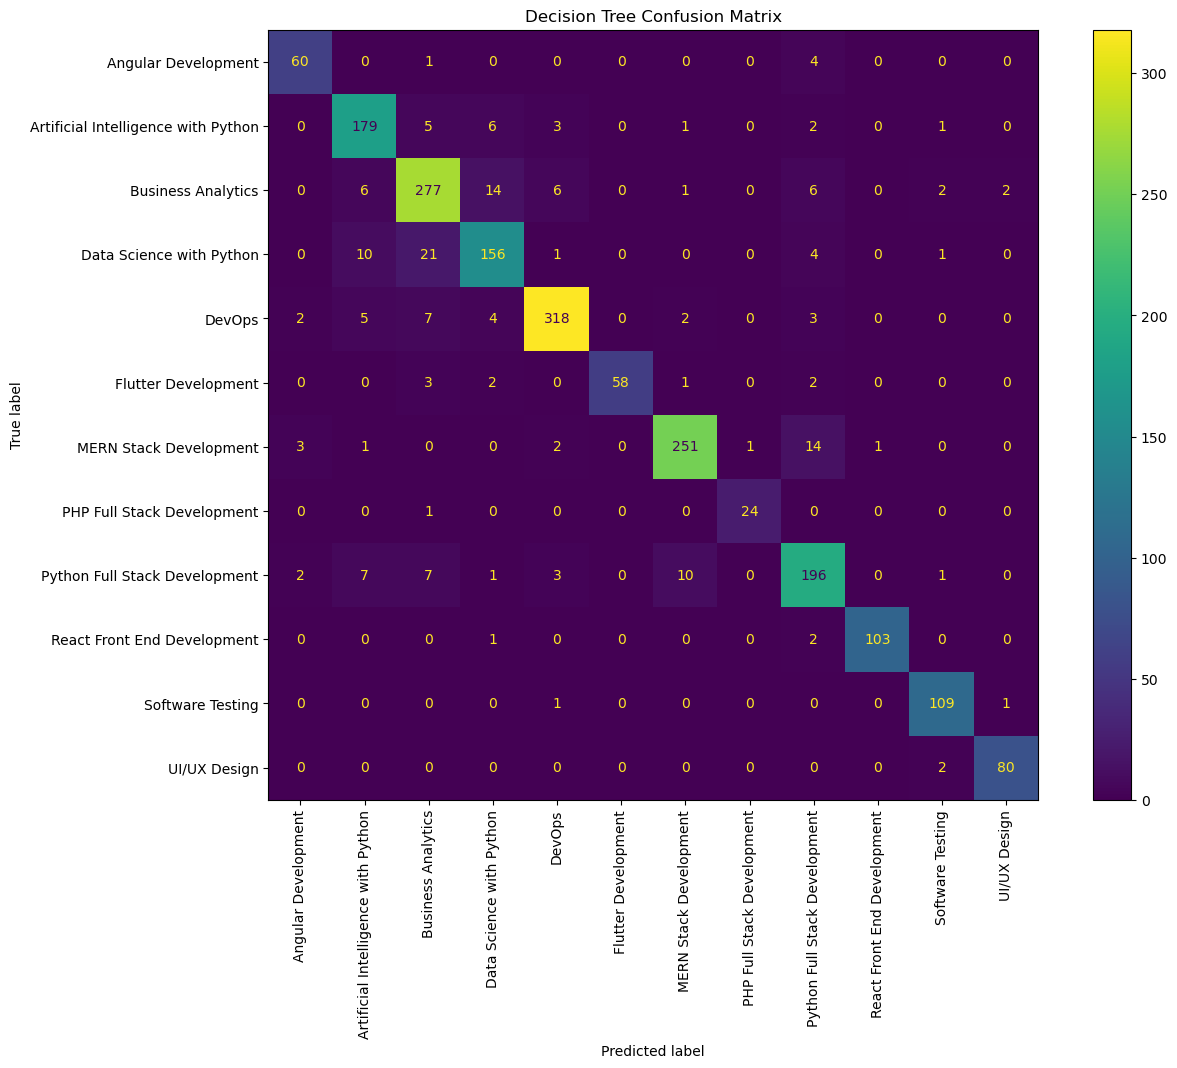

In [90]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_decision,display_labels=decision_model.classes_)
fig,ax = plt.subplots(figsize=(14,10))
disp.plot(ax=ax,xticks_rotation=90)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [91]:
decision_train_accuracy = accuracy_score(y_train,decision_model.predict(X_train_processed))

print(f"Decision Tree Training accuracy: {decision_train_accuracy*100}")
print(f"Decision Tree Test accuracy: {decision_accuracy*100}")

Decision Tree Training accuracy: 99.9625
Decision Tree Test accuracy: 90.55


The Decision Tree model achieved a training accuracy of **99.96%** and a test accuracy of **90.55%**.

The **9.41 percentage-point gap** between training and test accuracy indicates noticeable overfitting. The model performs extremely well on the training data but its performance decreases on unseen test data.

#### Feature Importance

In [92]:
feature_importance_dt = pd.DataFrame({
    "Features":X_train_processed.columns,
    "Importance":decision_model.feature_importances_
})

feature_importance_dt = feature_importance_dt.sort_values(by="Importance",ascending=False)

feature_importance_dt.head(10)

,Features,Importance
38,numerical__Q2,0.176631
41,numerical__Q5,0.140452
42,numerical__Q6,0.127251
40,numerical__Q4,0.075385
29,categorical__preferred_domain_MERN Stack,0.063794
33,categorical__preferred_domain_Testing,0.048249
32,categorical__preferred_domain_React,0.043759
43,numerical__Q8,0.041879
23,categorical__preferred_domain_AI/ML,0.031699
24,categorical__preferred_domain_Angular,0.025121


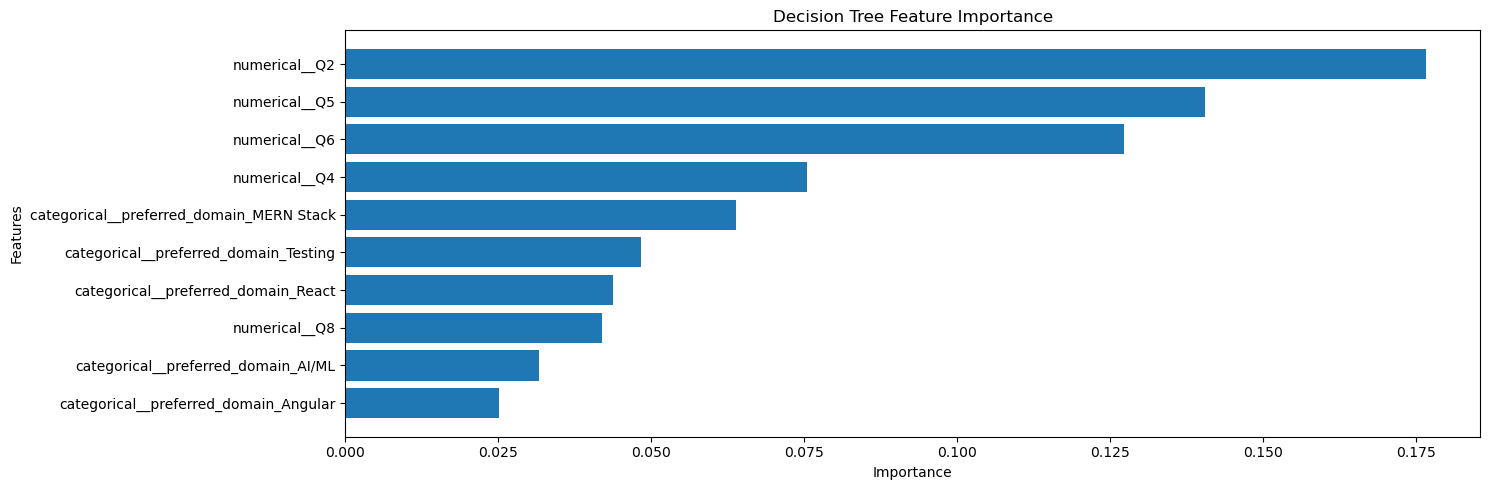

In [93]:
top_features_dt = feature_importance_dt.head(10)

plt.figure(figsize=(15,5))

plt.barh(top_features_dt["Features"][::-1],top_features_dt["Importance"][::-1])

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

#### Random Forest Classifier

A Random Forest classifier is trained as the third classification model.

Random Forest combines predictions from multiple decision trees instead of relying on a single tree. This can improve generalization and reduce the overfitting associated with an individual Decision Tree.

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [95]:
random_forest_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 15, 20, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

randomforest_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=random_forest_param_grid,
    n_iter=30,
    scoring = "f1_macro",
    cv=5,
    random_state=42,
    n_jobs=-1
)

randomforest_search.fit(X_train_processed,y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'class_weight': [None, 'balanced'], 'max_depth': [None, 15, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,30
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [96]:
print("Best Parameter: \n",randomforest_search.best_params_)
print("Best Macro F1: \n",randomforest_search.best_score_)

Best Parameter: 
 {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 25, 'class_weight': None}
Best Macro F1: 
 0.9041630619637054


In [97]:
randomforest_model = randomforest_search.best_estimator_

In [98]:
y_pred_forest = randomforest_model.predict(X_test_processed)

#### Model Evaluationn

In [99]:
forest_accuracy = accuracy_score(y_test,y_pred_forest)
class_report_forest = classification_report(y_test,y_pred_forest)
cm_forest = confusion_matrix(y_test,y_pred_forest)
forest_f1 = f1_score(y_test,y_pred_forest,average="macro")

print(f"Random Forest Accuracy: {forest_accuracy:.4f}")
print(f"Random Forest Macro F1: {forest_f1:.4f} ")
print("Random Forest classification report: \n", class_report_forest)

Random Forest Accuracy: 0.9110
Random Forest Macro F1: 0.9170 
Random Forest classification report: 
                                      precision    recall  f1-score   support

                Angular Development       0.83      0.98      0.90        65
Artificial Intelligence with Python       0.91      0.94      0.93       197
                 Business Analytics       0.90      0.93      0.92       314
           Data Science with Python       0.94      0.84      0.89       193
                             DevOps       0.95      0.96      0.95       341
                Flutter Development       0.95      0.89      0.92        66
             MERN Stack Development       0.89      0.89      0.89       273
         PHP Full Stack Development       0.89      0.96      0.92        25
      Python Full Stack Development       0.81      0.78      0.79       227
        React Front End Development       0.91      0.98      0.95       106
                   Software Testing       0.98    

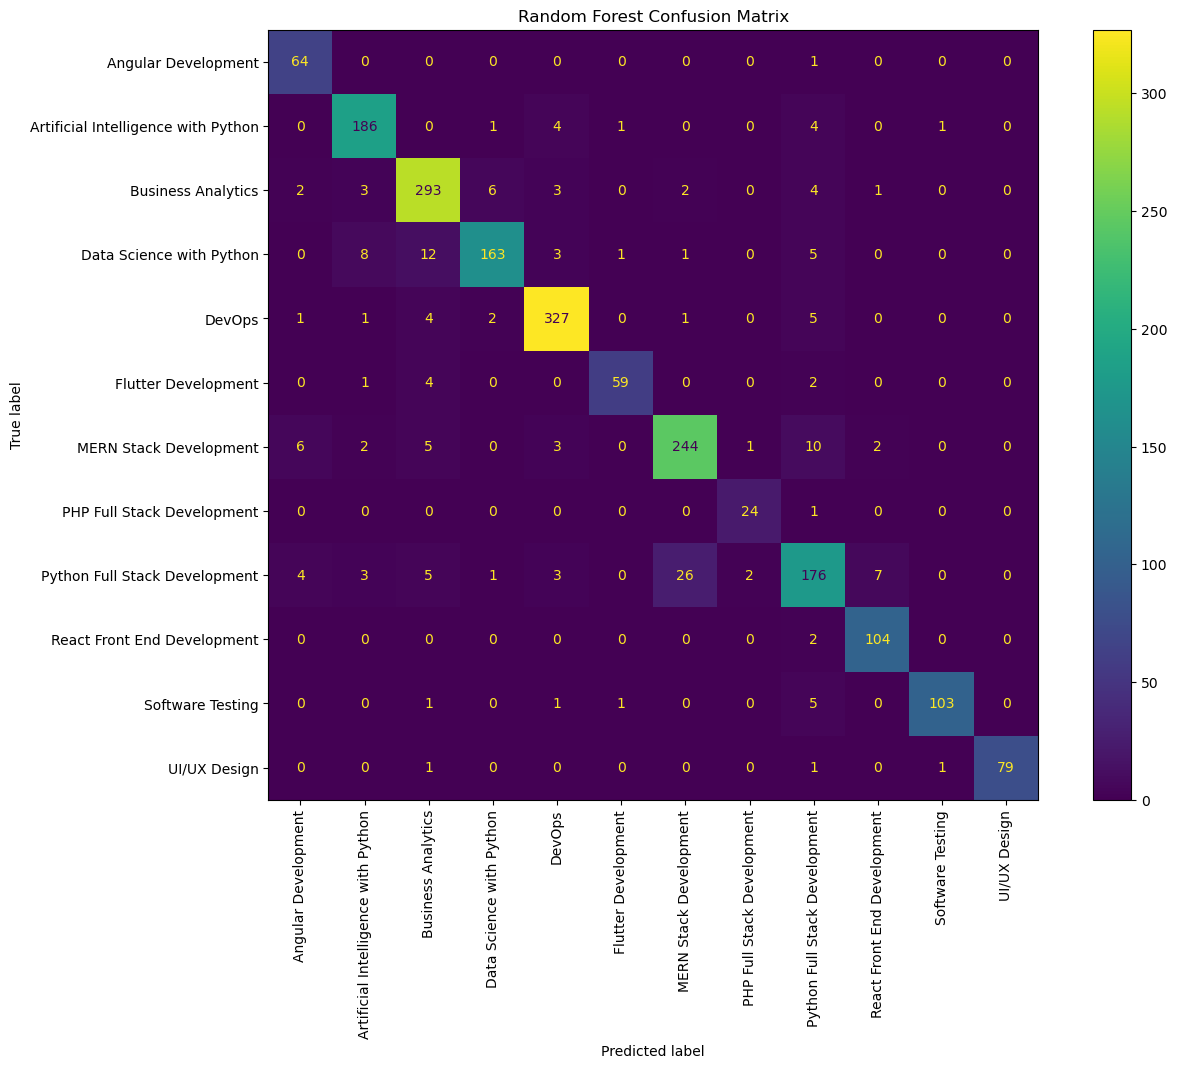

In [100]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_forest,display_labels=randomforest_model.classes_)

fig,ax = plt.subplots(figsize=(14,10))

disp.plot(ax=ax,xticks_rotation=90)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [101]:
forest_train_accuracy = accuracy_score(y_train,randomforest_model.predict(X_train_processed))

print(f"Random Forest Training Accuracy: {forest_train_accuracy*100:.2f}")
print(f"Random Forest Test Accuracy: {forest_accuracy*100:.2f}")

Random Forest Training Accuracy: 98.92
Random Forest Test Accuracy: 91.10


The Random Forest model achieved a training accuracy of **98.92%** and a test accuracy of **91.10%**.

The **7.82 percentage-point gap** between training and test accuracy indicates some overfitting. However, the model still maintains good performance on unseen data, suggesting reasonable generalization.

#### Feature Importance

In [102]:
feature_importance_rf = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": randomforest_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_rf.head(10)

,Feature,Importance
29,categorical__preferred_domain_MERN Stack,0.077507
27,categorical__preferred_domain_DevOps,0.069086
42,numerical__Q6,0.065308
38,numerical__Q2,0.063605
41,numerical__Q5,0.058098
40,numerical__Q4,0.045199
32,categorical__preferred_domain_React,0.042656
26,categorical__preferred_domain_Data Science,0.038212
44,numerical__Q9,0.031063
25,categorical__preferred_domain_Business Analytics,0.029776


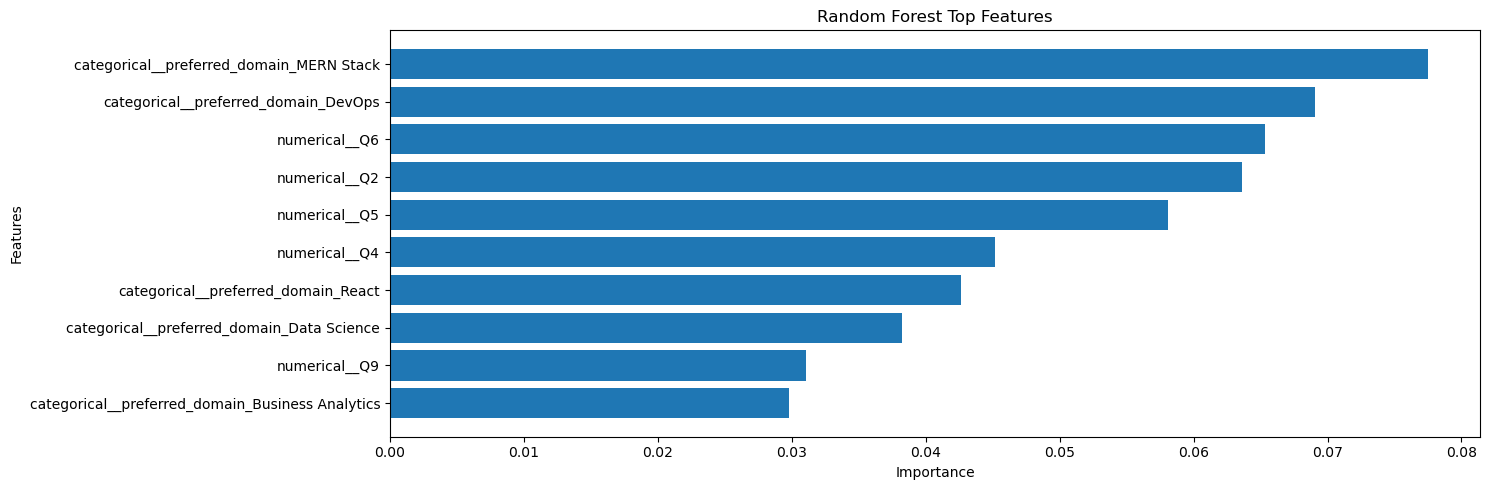

In [103]:
top_features_forest = feature_importance_rf.head(10)

plt.figure(figsize=(15,5))

plt.barh(top_features_forest["Feature"][::-1],top_features_forest["Importance"][::-1])

plt.title("Random Forest Top Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

#### Gradient Boosting Classifier

Gradient Boosting is evaluated as an additional ensemble learning model.

Unlike Random Forest, which builds multiple trees independently, Gradient Boosting builds trees sequentially. Each new tree attempts to improve the errors made by the previous trees.

In [104]:
from sklearn.ensemble import GradientBoostingClassifier

In [105]:
gradient_param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "subsample": [0.8, 1.0]
}

gradient_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gradient_param_grid,
    n_iter=10,
    scoring="f1_macro",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [106]:
gradient_search.fit(X_train_processed,y_train)

,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [107]:
print("Best Parameter: \n",gradient_search.best_params_)
print("Best Macro F1: \n",gradient_search.best_score_)

Best Parameter: 
 {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.2}
Best Macro F1: 
 0.9522309554227582


In [108]:
gradient_model = gradient_search.best_estimator_

In [109]:
y_pred_gradient = gradient_model.predict(X_test_processed)

#### Model Evaluation

In [110]:
gradient_accuracy = accuracy_score(y_test,y_pred_gradient)
class_report_gradient = classification_report(y_test,y_pred_gradient)
cm_gradient = confusion_matrix(y_test,y_pred_gradient)
gradient_f1 = f1_score(y_test,y_pred_gradient,average = "macro")

print(f"Gradient Boost Accuracy: {gradient_accuracy:.4f}")
print(f"Gradient Boost Macro F1: {gradient_f1:.4f}")
print("Gradient Boost classification report: \n",class_report_gradient)

Gradient Boost Accuracy: 0.9495
Gradient Boost Macro F1: 0.9499
Gradient Boost classification report: 
                                      precision    recall  f1-score   support

                Angular Development       0.94      0.98      0.96        65
Artificial Intelligence with Python       0.97      0.93      0.95       197
                 Business Analytics       0.94      0.97      0.95       314
           Data Science with Python       0.95      0.95      0.95       193
                             DevOps       0.97      0.97      0.97       341
                Flutter Development       1.00      0.94      0.97        66
             MERN Stack Development       0.95      0.94      0.94       273
         PHP Full Stack Development       0.95      0.84      0.89        25
      Python Full Stack Development       0.89      0.89      0.89       227
        React Front End Development       0.97      0.98      0.98       106
                   Software Testing       0.96  

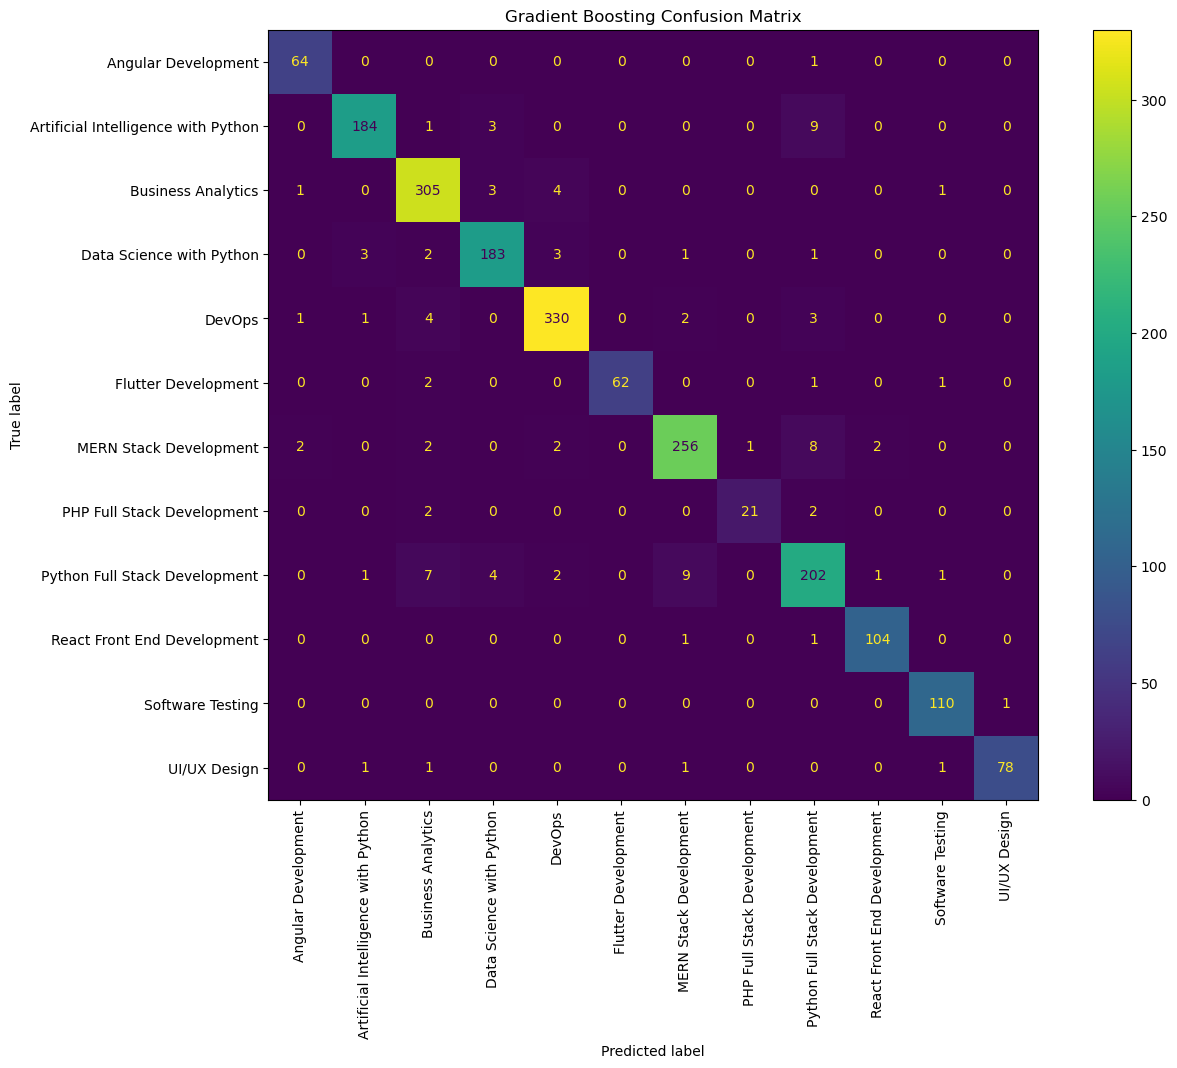

In [111]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gradient,display_labels=gradient_model.classes_)

fig,ax = plt.subplots(figsize=(14,10))

disp.plot(ax=ax,xticks_rotation=90)

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

In [112]:
GB_train_accuracy = accuracy_score(y_train,gradient_model.predict(X_train_processed))

print(f"Gradient Boosting Training accuracy: {GB_train_accuracy*100}")
print(f"Gradient Boosting Test accuracy: {gradient_accuracy*100}")

Gradient Boosting Training accuracy: 99.75
Gradient Boosting Test accuracy: 94.95


The Gradient Boosting model achieved a training accuracy of **99.75%** and a test accuracy of **94.95%**.

The **4.80 percentage-point gap** between training and test accuracy indicates a small amount of overfitting. However, the high test accuracy shows that the model still generalizes well to unseen data.



#### Feature Importance

In [113]:
feature_importance_GB = pd.DataFrame({
    "Features":X_train_processed.columns,
    "Importance":gradient_model.feature_importances_
})

feature_importance_GB = feature_importance_GB.sort_values(by="Importance",ascending=False)
feature_importance_GB.head(10)

,Features,Importance
27,categorical__preferred_domain_DevOps,0.145636
29,categorical__preferred_domain_MERN Stack,0.127370
41,numerical__Q5,0.065778
38,numerical__Q2,0.064368
26,categorical__preferred_domain_Data Science,0.054081
25,categorical__preferred_domain_Business Analytics,0.052801
32,categorical__preferred_domain_React,0.042991
23,categorical__preferred_domain_AI/ML,0.041610
33,categorical__preferred_domain_Testing,0.039481
31,categorical__preferred_domain_Python,0.038793


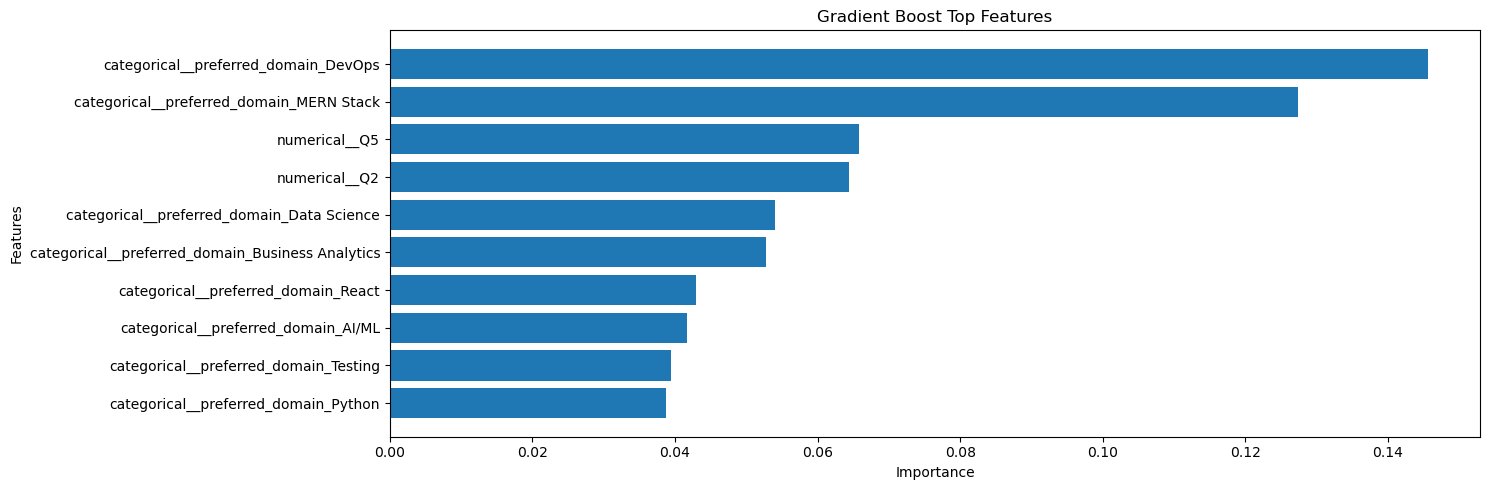

In [114]:
top_features_GB = feature_importance_GB.head(10)

plt.figure(figsize=(15,5))

plt.barh(top_features_GB["Features"][::-1],top_features_GB["Importance"][::-1])

plt.title("Gradient Boost Top Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [115]:
model_results = pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest","Gradient Boosting"],
    "Test Accuracy":[logistic_accuracy,decision_accuracy,forest_accuracy,gradient_accuracy],
    "Training Accuracy":[logistic_train_accuracy,decision_train_accuracy,forest_train_accuracy,GB_train_accuracy],
    "Macro F1":[logistic_f1,decision_f1,forest_f1,gradient_f1]
})

model_results = model_results.sort_values(by="Test Accuracy",ascending=False).reset_index(drop=True)
model_results

,Model,Test Accuracy,Training Accuracy,Macro F1
0,Gradient Boosting,0.9495,0.997500,0.949900
1,Random Forest,0.9110,0.989250,0.916983
2,Decision Tree,0.9055,0.999625,0.918661
3,Logistic Regression,0.9005,0.943500,0.908241


Out of all the models evaluated Gradient Boosting is our best performing model

#### Testing New Student Entry

In [116]:
new_student = {
    "name": "Lamine Yamal",
    "email": "lamine@example.com",
    "phone": "9876543210",
    "age": 22,
    "gender": "Male",
    "college": "Yenepoya Institute",
    "education_level": "Undergraduate",
    "qualification": "BCA",
    "specialization": "Artificial Intelligence, Machine Learning and Robotics",
    "graduation_year": 2025,
    "background": "No",
    "cgpa": 7.14,
    "backlogs": "No",
    "preferred_domain": "Data Science"
}

new_student_skills = {
    "Python": 4,
    "SQL": 3,
    "Excel": 4,
    "Power BI": 2,
    "Statistics": 3
}

new_student_questions = {
    "Q1": 4,
    "Q2": 4,
    "Q3": 3,
    "Q4": 5,
    "Q5": 4,
    "Q6": 3,
    "Q7": 2,
    "Q8": 4,
    "Q9": 3,
    "Q10": 4
}

### Reusable Student Recommendation Pipeline

The trained Gradient Boosting model has been selected as the final recommendation model based on its evaluation performance.

The new student workflow is now converted into reusable functions so that the same feature preparation and prediction process can be applied to any student.

The students profile information, questionnaire responses, and selected skills are converted into the feature structure expected by the trained preprocessing pipeline. The processed data is then passed to the Gradient Boosting model to generate the Top 3 course recommendations.

The recommendation system will later be extended with student friendly explanations describing why each course was recommended.

In [117]:
def prepare_student_features(student_info,student_skills,student_questions):
    """
    Convert a student's profile, selected skills, and questionnaire
    responses into the processed feature format expected by the ML model.

    Parameters:
        student_info (dict): Student profile information used by the ML model.

        student_skills (dict): Skills selected by the student with ratings from 0-5.

        student_questions (dict): Questionnaire responses.

    Returns:
        DataFrame: Processed feature data ready for the ML model.
    """

    # Create an empty row using the exact features
    student_row = pd.DataFrame(
        0,
        index=[0],
        columns=preprocessor.feature_names_in_
    )

    # Add Profile information
    for feature,value in student_info.items():
        if feature in student_row.columns:
            student_row[feature] = value

    # ADd questionare response
    for question,response in student_questions.items():
        if question in student_row.columns:
            student_row[question] = response

    # Add selected skills and their ratings
    for skill,rating in student_skills.items():
        if skill in student_row.columns:
            student_row[skill] = rating

    # Applying the preprocessing used in model training
    processed_student = preprocessor.transform(student_row)

    return processed_student
    

In [118]:
new_student_processed = prepare_student_features(new_student,new_student_skills,new_student_questions)

print("Processed studnet shape: ",new_student_processed.shape)

Processed studnet shape:  (1, 118)


#### Top 3 Recommendation

In [119]:
def recommend_top3(student_data):
    """
    Return the three highest-ranked course recommendations
    using the Gradient Boosting model.
    
    """
    #empty list to store recommendation
    recommendations = []
    
    # get the probabilities for every course
    probabilities = gradient_model.predict_proba(student_data)

    # probabilities for this student
    student_prob = probabilities[0]

    # find the indices of the 3 hihest probabilities
    top3_indices = np.argsort(student_prob)[-3:][::-1]

    # Converts to course name
    for rank,index in enumerate(top3_indices,start=1):
        recommendations.append({
            "Rank":rank,
            "Course":gradient_model.classes_[index],
            "Probability":student_prob[index]*100
        })

    return pd.DataFrame(recommendations)

    

In [120]:
new_student_recommendations = recommend_top3(new_student_processed)

new_student_recommendations

,Rank,Course,Probability
0,1,Artificial Intelligence with Python,98.527293
1,2,Data Science with Python,0.612779
2,3,Python Full Stack Development,0.594839


### Generate Recommendation Explanations

The recommendation model identifies the courses that best match the students overall profile. This section adds a separate explanation layer that uses the students profile, questionnaire responses, existing skills, and the recommended course information to explain why each course was recommended.

The explanation layer does not change the machine learning prediction. It only provides understandable reasons and supporting information for the recommendations.

In [121]:
def get_skill_matches(student_skills, course_profile):
    """
    Identify the students matching and missing skills for a course.

    Parameters:
        student_skills (dict):Student's existing skills and their ratings.

        course_profile (dict):Course profile created using build_course_profile().

    Returns:
        tuple:
            matched_skills: Skills the student already has.
            missing_skills: Course skills the student does not have.
    """

    course_skills = course_profile["skills"]

    matched_sklls = []
    missing_skills= []

    for skill in course_skills:
        if skill in student_skills:
            matched_sklls.append(f"{skill} ({student_skills[skill]}/5)")

        else:
            missing_skills.append(skill)
    return matched_sklls,missing_skills

In [122]:
course_profile = build_course_profile(
    courses_df[courses_df["course_name"] == "Artificial Intelligence with Python"].iloc[0]
)


matched_skills_new,missing_skills_new = get_skill_matches(new_student_skills,course_profile)

print("Matched skills:", matched_skills_new)
print("Missing skills:", missing_skills_new)

Matched skills: ['Python (4/5)']
Missing skills: ['Machine Learning', 'Deep Learning', 'NLP']


#### Skill explanation

In [123]:
def generate_skill_explanation(matched_skills,missing_skills):
    """
    Generate a simple explanation based on the student's
    existing and missing course skills.

    Parameters:
        matched_skills (list):Skills the student already has.

        missing_skills (list):Skills required by the course that the studenthas not selected.

    Returns:
        list:
            Humanbreadable explanation points.
    """

    explanation = []

    # Explain existing skills
    if matched_skills:
        explanation.append("You already have relevant skills: " + ", ".join(matched_skills) + ".")

    # Explain skills that can be developed
    if missing_skills:
        explanation.append("You can develop additional skills such as " + ", ".join(missing_skills) + " through this course.")

    return explanation

In [124]:
skill_exp = generate_skill_explanation(matched_skills_new,missing_skills_new)

skill_exp

['You already have relevant skills: Python (4/5).',
 'You can develop additional skills such as Machine Learning, Deep Learning, NLP through this course.']

### Domain explanation 

In [125]:
def generate_domain_explanation(preferred_domain, course_profile):
    """
    Generate an explanation based on the student's preferred
    domain and the course category.

    Returns:
        list: Human readable domain explanation points.
    """

    course_category = course_profile["course_info"]["category"]

    explanation = []

    if preferred_domain == course_category:
        explanation.append(f"Your preferred domain is {preferred_domain},"
                          f" which directly matches this course.")
    else:
        explanation.append(f"Your preferred domain is {preferred_domain}, "
                          f" and this {course_category} course provides a related learning path.")

    return explanation
    

In [126]:
domain_exp= generate_domain_explanation(new_student["preferred_domain"],course_profile)
domain_exp

['Your preferred domain is Data Science,  and this AI/ML course provides a related learning path.']

#### Generate Interest Explanation

The questionnaire responses are already used by the recommendation system to calculate an interest score for each course category. This function reuses that existing calculation and converts the score into a simple explanation for the student.

The explanation does not modify the model prediction or recommendation score.

In [127]:
def generate_interest_explanation(student_answers,course_category):
    """
    Generate a human readable explanation based on the student's
    questionnaire interest in the course category.

    Parameters:
        student_answers (dict):
            Students questionnaire responses.

        course_category (str):
            Category of the recommended course.

    Returns:
        list:
            Human readable interest explanation points.
    """

    # Use the existing interest score calculation
    temp_student_profile = {
        "answers":student_answers
    }

    interest_score = calculate_interest_score(temp_student_profile,course_category)

    explanation = []

    if interest_score >= 80:
        explanation.append(f"Your questionnaire responses show strong interest"
                          f" in this area ({interest_score:.0f}/100).")
    elif interest_score >= 60:
        explanation.append(f"Your questionnaire responses show good interest"
                          f" in this area ({interest_score:.0f}/100).")
    elif interest_score >=40:
        explanation.append(f"Your questionnaire responses show moderate interest"
                          f" in this area ({interest_score:.0f}/100).")
    else:
        explanation.append(f"Your questionnaire responses show limited interest"
                           f" in this area ({interest_score:.0f}/100).")

    return explanation


In [128]:
interest_exp = generate_interest_explanation(new_student_questions,course_profile["course_info"]["category"])

interest_exp

['Your questionnaire responses show strong interest in this area (100/100).']

#### Generatet the Recommendation Explanation

In [129]:
def generate_recommendation_explanation(student,student_skills,student_questions,course_profile):
    """
    The explanation combines:
    - Existing and missing skills
    - Preferred domain
    - Questionnaire interest

    Parameters:
        student (dict):
            Student information.

        student_skills (dict):
            Student's existing skills and ratings.

        student_questions (dict):
            Student's questionnaire responses.

        course_profile (dict):
            Course profile created using build_course_profile().

    Returns:
        dict:
            Contains the explanation points and skill information.
    """

    # get skill mathces 
    matched_skills,missing_skills = get_skill_matches(student_skills,course_profile)

    # generate skill explanation
    skill_explanation = generate_skill_explanation(matched_skills,missing_skills)

    # generate domain explanations
    domain_explanation = generate_domain_explanation(student["preferred_domain"],course_profile)

    # generate qustionnaire explanation
    interest_explanation = generate_interest_explanation(
        student_questions,course_profile["course_info"]["category"]
    )

    explanation = (
        domain_explanation +
        skill_explanation +
        interest_explanation
    )

    return {
        "explanation":explanation,
        "matched_skills": matched_skills,
        "missing_skills":missing_skills
    }

In [130]:
recommendation_explanation = generate_recommendation_explanation(
    new_student,
    new_student_skills,
    new_student_questions,
    course_profile
)

for point in recommendation_explanation["explanation"]:
    print("->",point)
    
print("\nMatched skills:")
print(recommendation_explanation["matched_skills"])

print("\nMissing skills:")
print(recommendation_explanation["missing_skills"])

-> Your preferred domain is Data Science,  and this AI/ML course provides a related learning path.
-> You already have relevant skills: Python (4/5).
-> You can develop additional skills such as Machine Learning, Deep Learning, NLP through this course.
-> Your questionnaire responses show strong interest in this area (100/100).

Matched skills:
['Python (4/5)']

Missing skills:
['Machine Learning', 'Deep Learning', 'NLP']


In [131]:
def generate_final_result(recommendation,student,student_skills,student_questions):
    """
    Generate the final Top-3 course recommendations with
    course details and student-specific explanations.
    """
    final_results = []
    
    for _, row in recommendation.iterrows():
        # get the course row
        course_row = courses_df[courses_df["course_name"] == row["Course"]].iloc[0]

        # build the course profile
        course_profile = build_course_profile(course_row)
    
        # call the generate_recommendation_explanation() function
        explanation = generate_recommendation_explanation(
            student,
            student_skills,
            student_questions,
            course_profile
        )

        # store to final result list in dict format
        final_results.append({
            "rank": int(row["Rank"]),
            "course_name":row["Course"],
            "probability": row["Probability"],
            "course_desc":course_row["course_description"],
            "explanation": explanation["explanation"],
            "matched_skills": explanation["matched_skills"],
            "missing_skills": explanation["missing_skills"]
        })

    # Display the recommendations
    for result in final_results:

        print("\n" + "=" * 60)
        print(f"{result["rank"]}. {result["course_name"]}")
        print("="*60)
    
        print(f"\n Recommendation Probability {result["probability"]:.4f}",)
        print(f"\n About the Course:")
        print(result["course_desc"])
    
        print("\nWhy this Course")
        for point in result["explanation"]:
            print("-> ",point)
    
        if result["missing_skills"]:
            print("\nSkils You Can develop ")
    
            for skill in result["missing_skills"]:
                print("-> ",skill)
   

In [132]:
new_student_recommendations

,Rank,Course,Probability
0,1,Artificial Intelligence with Python,98.527293
1,2,Data Science with Python,0.612779
2,3,Python Full Stack Development,0.594839


In [133]:
final_result1 = generate_final_result(new_student_recommendations,new_student,new_student_skills,new_student_questions)
final_result1


1. Artificial Intelligence with Python

 Recommendation Probability 98.5273

 About the Course:
Understand AI and machine learning concepts using Python.

Why this Course
->  Your preferred domain is Data Science,  and this AI/ML course provides a related learning path.
->  You already have relevant skills: Python (4/5).
->  You can develop additional skills such as Machine Learning, Deep Learning, NLP through this course.
->  Your questionnaire responses show strong interest in this area (100/100).

Skils You Can develop 
->  Machine Learning
->  Deep Learning
->  NLP

2. Data Science with Python

 Recommendation Probability 0.6128

 About the Course:
Learn data analysis, visualization and machine learning using Python.

Why this Course
->  Your preferred domain is Data Science, which directly matches this course.
->  You already have relevant skills: Python (4/5).
->  You can develop additional skills such as Pandas, NumPy, Matplotlib, Scikit-learn through this course.
->  Your ques

In [134]:
new_student_2 = {
    "name": "Rahul Menon",
    "email": "rahul@example.com",
    "phone": "9876543210",
    "age": 21,
    "gender": "Male",
    "college": "ABC College",
    "education_level": "Undergraduate",
    "qualification": "BCA",
    "specialization": "Computer Applications",
    "graduation_year": 2026,
    "background": "Yes",
    "cgpa": 7.8,
    "backlogs": "No",
    "preferred_domain": "React"
}
new_student_2_skills = {
    "HTML": 5,
    "CSS": 5,
    "JavaScript": 4,
    "React": 4,
    "Git": 3
}
new_student_2_questions = {
    "Q1": 4,
    "Q2": 5,
    "Q3": 2,
    "Q4": 2,
    "Q5": 2,
    "Q6": 2,
    "Q7": 3,
    "Q8": 3,
    "Q9": 3,
    "Q10": 4
}

In [135]:
student_2_processed = prepare_student_features(new_student_2,new_student_2_skills,new_student_2_questions)

student_2_processed.shape

(1, 118)

In [136]:
student2_recommendation = recommend_top3(student_2_processed)

student2_recommendation

,Rank,Course,Probability
0,1,React Front End Development,99.924794
1,2,Angular Development,0.074752
2,3,MERN Stack Development,0.000439


In [137]:
final_result2 = generate_final_result(student2_recommendation,new_student_2,new_student_2_skills,new_student_2_questions)

final_result2


1. React Front End Development

 Recommendation Probability 99.9248

 About the Course:
Build responsive and interactive frontend applications using React.

Why this Course
->  Your preferred domain is React, which directly matches this course.
->  You already have relevant skills: React (4/5), JavaScript (4/5), HTML (5/5), CSS (5/5).
->  You can develop additional skills such as API Integration through this course.
->  Your questionnaire responses show strong interest in this area (100/100).

Skils You Can develop 
->  API Integration

2. Angular Development

 Recommendation Probability 0.0748

 About the Course:
Create scalable web applications using Angular and TypeScript.

Why this Course
->  Your preferred domain is React,  and this Angular course provides a related learning path.
->  You already have relevant skills: HTML (5/5), CSS (5/5).
->  You can develop additional skills such as Angular, TypeScript, RxJS through this course.
->  Your questionnaire responses show strong int

In [138]:
new_student_3 = {
    "name": "Ananya Nair",
    "email": "ananya@example.com",
    "phone": "9876543211",
    "age": 20,
    "gender": "Female",
    "college": "ABC College",
    "education_level": "Undergraduate",
    "qualification": "B.Com",
    "specialization": "Commerce",
    "graduation_year": 2026,
    "background": "No",
    "cgpa": 7.2,
    "backlogs": "No",
    "preferred_domain": "Python"
}

new_student_3_skills = {
    "Python": 1
}

new_student_3_questions = {
    "Q1": 1,
    "Q2": 4,
    "Q3": 4,
    "Q4": 2,
    "Q5": 3,
    "Q6": 2,
    "Q7": 2,
    "Q8": 4,
    "Q9": 4,
    "Q10": 4
}

In [139]:
student3_processed = prepare_student_features(new_student_3,new_student_3_skills,new_student_3_questions)

student3_processed.shape

(1, 118)

In [140]:
student3_recommendation = recommend_top3(student3_processed)

student3_recommendation

,Rank,Course,Probability
0,1,Software Testing,60.072624
1,2,Python Full Stack Development,35.539604
2,3,UI/UX Design,1.806139


In [141]:
final_result3 = generate_final_result(student3_recommendation,new_student_3,new_student_3_skills,new_student_3_questions)


1. Software Testing

 Recommendation Probability 60.0726

 About the Course:
Learn manual and automation testing techniques.

Why this Course
->  Your preferred domain is Python,  and this Testing course provides a related learning path.
->  You can develop additional skills such as Manual Testing, Selenium, TestNG, Bug Tracking through this course.
->  Your questionnaire responses show strong interest in this area (80/100).

Skils You Can develop 
->  Manual Testing
->  Selenium
->  TestNG
->  Bug Tracking

2. Python Full Stack Development

 Recommendation Probability 35.5396

 About the Course:
Learn Python, Django, REST APIs, MySQL, Git and build full-stack web applications.

Why this Course
->  Your preferred domain is Python, which directly matches this course.
->  You already have relevant skills: Python (1/5).
->  You can develop additional skills such as Django, HTML, CSS, JavaScript, MySQL, REST API, Git through this course.
->  Your questionnaire responses show strong intere

In [142]:
new_student_3_questions_b = {
    "Q1": 3,
    "Q2": 2,
    "Q3": 1,
    "Q4": 4,
    "Q5": 4,
    "Q6": 2,
    "Q7": 1,
    "Q8": 2,
    "Q9": 2,
    "Q10": 4
}

In [143]:
student_3_processed_b = prepare_student_features(
    new_student_3,
    new_student_3_skills,
    new_student_3_questions_b
)
student3_recommendation_b = recommend_top3(
    student_3_processed_b
)

student3_recommendation_b

,Rank,Course,Probability
0,1,Data Science with Python,72.669238
1,2,Business Analytics,13.977229
2,3,Artificial Intelligence with Python,9.661383


In [144]:
final_result_b = generate_final_result(
    student3_recommendation_b,
    new_student_3,
    new_student_3_skills,
    new_student_3_questions_b
)


1. Data Science with Python

 Recommendation Probability 72.6692

 About the Course:
Learn data analysis, visualization and machine learning using Python.

Why this Course
->  Your preferred domain is Python,  and this Data Science course provides a related learning path.
->  You already have relevant skills: Python (1/5).
->  You can develop additional skills such as Pandas, NumPy, Matplotlib, Scikit-learn through this course.
->  Your questionnaire responses show strong interest in this area (80/100).

Skils You Can develop 
->  Pandas
->  NumPy
->  Matplotlib
->  Scikit-learn

2. Business Analytics

 Recommendation Probability 13.9772

 About the Course:
Analyze business data to support strategic decision making.

Why this Course
->  Your preferred domain is Python,  and this Business Analytics course provides a related learning path.
->  You can develop additional skills such as Excel, SQL, Power BI, Data Analysis through this course.
->  Your questionnaire responses show strong i

In [145]:
new_student_4 = {
    "name": "Arjun Kumar",
    "email": "arjun@example.com",
    "phone": "9876543212",
    "age": 23,
    "gender": "Male",
    "college": "ABC College",
    "education_level": "Undergraduate",
    "qualification": "B.Com",
    "specialization": "Commerce",
    "graduation_year": 2025,
    "background": "Yes",
    "cgpa": 7.6,
    "backlogs": "No",
    "preferred_domain": "Business Analytics"
}

new_student_4_skills = {
    "Excel": 5,
    "SQL": 4,
    "Power BI": 4,
    "Data Analysis": 4
}

new_student_4_questions = {
    "Q1": 3,
    "Q2": 2,
    "Q3": 1,
    "Q4": 2,
    "Q5": 5,
    "Q6": 2,
    "Q7": 1,
    "Q8": 2,
    "Q9": 2,
    "Q10": 5
}

In [146]:
student_4_processed = prepare_student_features(
    new_student_4,
    new_student_4_skills,
    new_student_4_questions
)

student4_recommendation = recommend_top3(
    student_4_processed
)

student4_recommendation

,Rank,Course,Probability
0,1,Business Analytics,99.999646
1,2,Data Science with Python,0.000257
2,3,Python Full Stack Development,0.000049


In [147]:
final_results_4 = generate_final_result(
    student4_recommendation,
    new_student_4,
    new_student_4_skills,
    new_student_4_questions
)


1. Business Analytics

 Recommendation Probability 99.9996

 About the Course:
Analyze business data to support strategic decision making.

Why this Course
->  Your preferred domain is Business Analytics, which directly matches this course.
->  You already have relevant skills: Excel (5/5), SQL (4/5), Power BI (4/5), Data Analysis (4/5).
->  Your questionnaire responses show strong interest in this area (100/100).

2. Data Science with Python

 Recommendation Probability 0.0003

 About the Course:
Learn data analysis, visualization and machine learning using Python.

Why this Course
->  Your preferred domain is Business Analytics,  and this Data Science course provides a related learning path.
->  You can develop additional skills such as Python, Pandas, NumPy, Matplotlib, Scikit-learn through this course.
->  Your questionnaire responses show strong interest in this area (100/100).

Skils You Can develop 
->  Python
->  Pandas
->  NumPy
->  Matplotlib
->  Scikit-learn

3. Python Full